# BigMart Sales Prediction — Regression

**Founder pitch context:** This notebook builds the machine learning engine behind a retail
sales-forecasting web app. The business problem: a supermarket chain (BigMart) wants to predict
`Item_Outlet_Sales` — the revenue a specific product generates at a specific store — so that
category managers can plan inventory, evaluate store performance, and prioritise which
products/outlets to stock more aggressively.

**Task type:** Regression (target `Item_Outlet_Sales` is continuous).

**Dataset:** BigMart Sales Dataset, sourced from Kaggle:
https://www.kaggle.com/datasets/yasserh/bigmartsalesdataset (8,523 rows, 12 columns, real
historical retail transactions — not synthetically generated, not time-series-only, no
unstructured text/image columns).

**Notebook structure:**

| Section | Content |
|---|---|
| 1 | Data loading & inspection |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Data-quality diagnosis — deciding the cleaning rules |
| 4 | Feature engineering & evidence-based feature selection |
| 5 | Leakage-free preprocessing pipeline & train/test split |
| 6 | Evaluation metric justification & baseline models |
| 7 | Model comparison across four algorithms, with uncertainty |
| 8 | Feature importance analysis |
| 9 | Hyperparameter tuning (RandomizedSearchCV) & is the gain real? |
| 10 | Business impact & segment-level error analysis |
| 11 | Prediction intervals — quantifying forecast uncertainty |
| 12 | Final model selection, assumptions, limitations & export |

**A note on how this notebook is organised.** Sections 2–4 *diagnose* the data and *decide*
the preprocessing rules. Section 5 then *implements* every one of those rules as a
scikit-learn transformer inside the model pipeline, so that each rule is re-fitted from
scratch on the training rows of every cross-validation fold. This is deliberate and is
explained in Section 5: cleaning the full table up-front — the more common approach — leaks
test-set information into training and inflates every score that follows.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Narrow suppression rather than a blanket filterwarnings("ignore"): we silence only the
# known-noisy seaborn categorical-palette deprecation, so that any genuine convergence or
# data-quality warning from scikit-learn still surfaces instead of being hidden.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)

## 1. Data Loading & Inspection

In [2]:
DATA_PATH = "data/bigmart.csv"
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Item_Identifier,8523,1559,FDG33,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Weight,7060.0,NaN,NaN,NaN,12.857645,4.643456,4.555,8.77375,12.6,16.85,21.35
Item_Fat_Content,8523,5,Low Fat,5089,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_Visibility,8523.0,NaN,NaN,NaN,0.066132,0.051598,0.0,0.026989,0.053931,0.094585,0.328391
Item_Type,8523,16,Fruits and Vegetables,1232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item_MRP,8523.0,NaN,NaN,NaN,140.992782,62.275067,31.29,93.8265,143.0128,185.6437,266.8884
Outlet_Identifier,8523,10,OUT027,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Establishment_Year,8523.0,NaN,NaN,NaN,1997.831867,8.37176,1985.0,1987.0,1999.0,2004.0,2009.0
Outlet_Size,6113,3,Medium,2793,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Outlet_Location_Type,8523,3,Tier 3,3350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing values

Two columns have missing values: `Item_Weight` and `Outlet_Size`. We inspect the pattern
before deciding how to impute, since missing-at-random vs structurally-missing data call for
different strategies (investigated in Section 3).

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary

,missing_count,missing_pct
Item_Weight,1463,17.17
Outlet_Size,2410,28.28


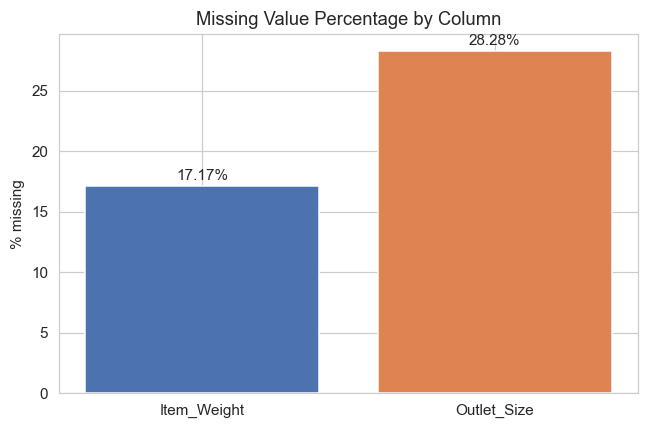

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(missing_summary.index, missing_summary["missing_pct"], color=["#4C72B0", "#DD8452"])
ax.set_ylabel("% missing")
ax.set_title("Missing Value Percentage by Column")
for i, v in enumerate(missing_summary["missing_pct"]):
    ax.text(i, v + 0.5, f"{v}%", ha="center")
plt.tight_layout()
plt.show()

## 2. Exploratory Data Analysis (EDA)

EDA is run on the **raw, uncleaned** data on purpose: the point of this section is to *find* the
data-quality problems, so fixing them first would hide the evidence for the decisions made in
Section 3. Nothing here is imputed — missing data is shown as missing.

Skewness of Item_Outlet_Sales: 1.18


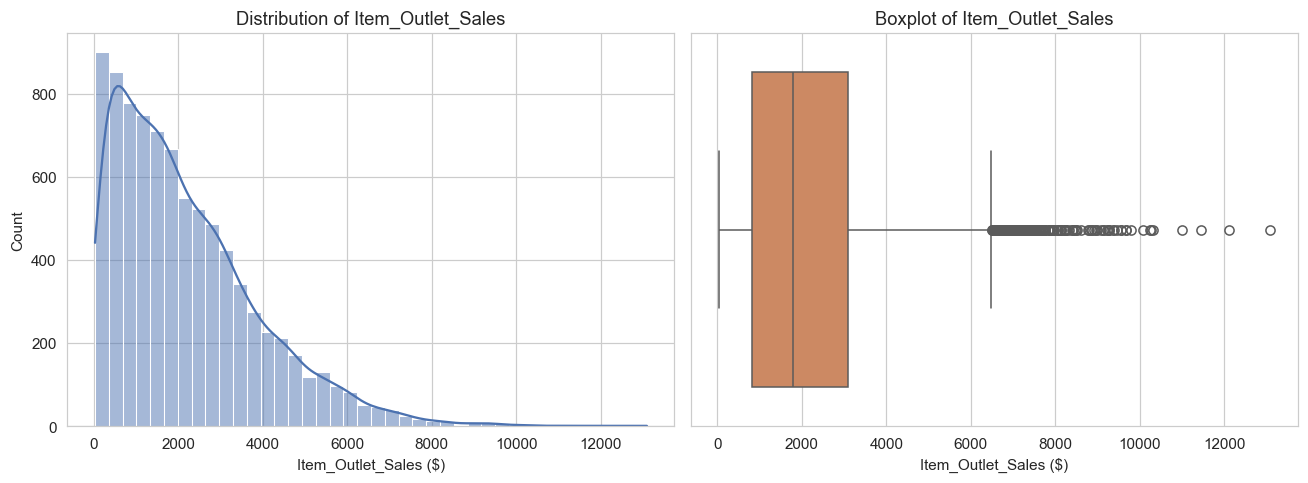

In [7]:
TARGET = "Item_Outlet_Sales"

skew_val = df[TARGET].skew()
print(f"Skewness of {TARGET}: {skew_val:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Item_Outlet_Sales")
axes[0].set_xlabel("Item_Outlet_Sales ($)")

sns.boxplot(x=df[TARGET], ax=axes[1], color="#DD8452")
axes[1].set_title("Boxplot of Item_Outlet_Sales")
axes[1].set_xlabel("Item_Outlet_Sales ($)")
plt.tight_layout()
plt.show()

**Interpretation:** The target is right-skewed (skew ≈ 1.18) — most products generate modest
revenue while a smaller number of high-MRP / high-traffic-outlet products drive very large sales.
This informs modelling: tree-based models handle this skew natively, while a log-transform is
worth testing for the linear baseline (tested in Section 6).

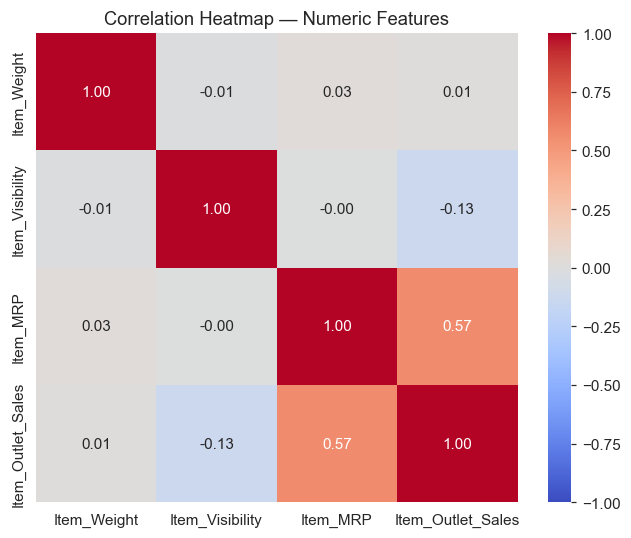

In [8]:
numeric_cols = ["Item_Weight", "Item_Visibility", "Item_MRP", TARGET]
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

**Interpretation:** `Item_MRP` (retail price) has the strongest correlation with sales
(~0.57) — unsurprising, since higher-priced items generate more revenue per unit sold.
`Item_Weight` and `Item_Visibility` show negligible linear correlation with the target on
their own, but may still interact with categorical features (e.g. outlet type), so we keep
them for now and revisit with feature importance later rather than dropping them on
correlation alone.

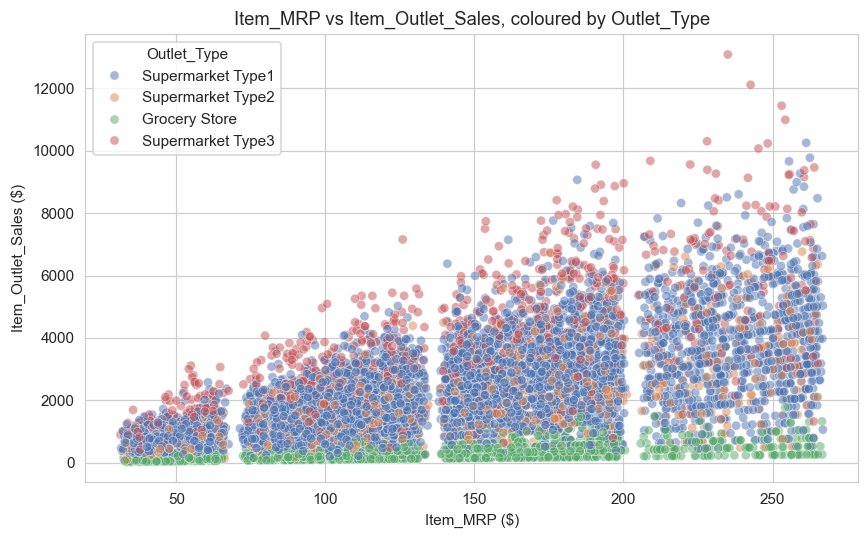

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df, x="Item_MRP", y=TARGET, hue="Outlet_Type", alpha=0.5, ax=ax, palette="deep"
)
ax.set_title("Item_MRP vs Item_Outlet_Sales, coloured by Outlet_Type")
ax.set_xlabel("Item_MRP ($)")
ax.set_ylabel("Item_Outlet_Sales ($)")
plt.tight_layout()
plt.show()

**Interpretation:** Sales roughly increase with MRP in four visible price "bands"
(a known characteristic of this dataset), and within every price band, Grocery Store outlets
consistently cluster at the bottom — i.e. `Outlet_Type` shifts the whole sales curve up or down
regardless of price. This is a strong signal that `Outlet_Type` will be an important
categorical predictor, and that the relationship is **non-linear with interactions**, which is
the modelling hypothesis tested in Section 7.

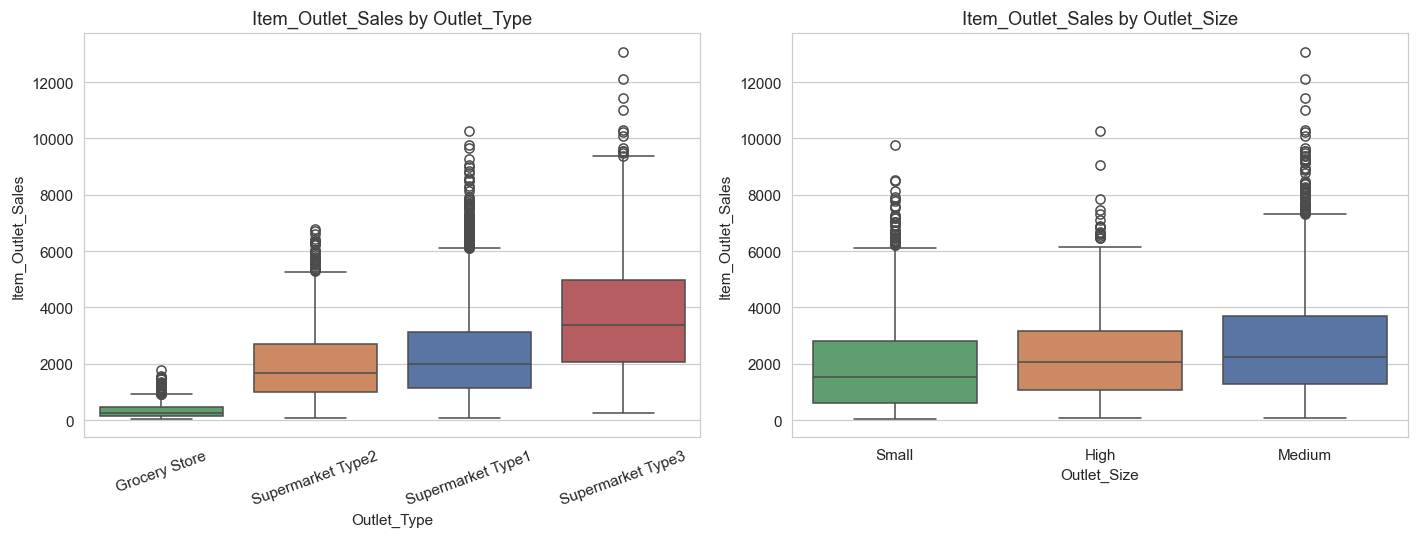

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order1 = df.groupby("Outlet_Type")[TARGET].median().sort_values().index
sns.boxplot(data=df, x="Outlet_Type", y=TARGET, order=order1, ax=axes[0],
            hue="Outlet_Type", palette="deep", legend=False)
axes[0].set_title("Item_Outlet_Sales by Outlet_Type")
axes[0].tick_params(axis="x", rotation=20)

order2 = df.groupby("Outlet_Size")[TARGET].median().sort_values().index
sns.boxplot(data=df, x="Outlet_Size", y=TARGET, order=order2, ax=axes[1],
            hue="Outlet_Size", palette="deep", legend=False)
axes[1].set_title("Item_Outlet_Sales by Outlet_Size")
plt.tight_layout()
plt.show()

**Interpretation:** `Grocery Store` outlets sell far less per item than any Supermarket
format — a key business insight: format conversion (Grocery → Supermarket) is a bigger sales
lever than any single product decision. Outlet size shows a weaker but visible relationship,
with `High` size outlets skewing toward higher sales.

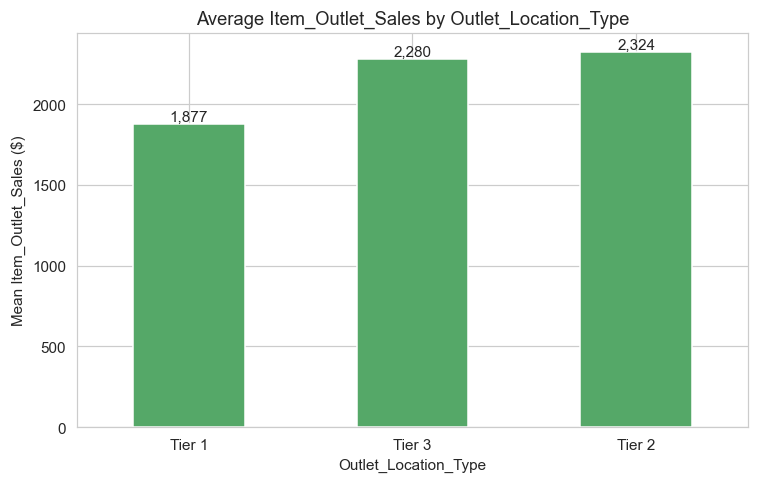

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
avg_by_loc = df.groupby("Outlet_Location_Type")[TARGET].mean().sort_values()
avg_by_loc.plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Average Item_Outlet_Sales by Outlet_Location_Type")
ax.set_ylabel("Mean Item_Outlet_Sales ($)")
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(avg_by_loc):
    ax.text(i, v + 20, f"{v:,.0f}", ha="center")
plt.tight_layout()
plt.show()

In [12]:
print("Item_Fat_Content raw categories:", df["Item_Fat_Content"].unique().tolist())
print("Item_Visibility == 0 count:", (df["Item_Visibility"] == 0).sum(),
      f"({(df['Item_Visibility'] == 0).mean()*100:.1f}% of rows)")

Item_Fat_Content raw categories: ['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Item_Visibility == 0 count: 526 (6.2% of rows)


### EDA summary — implications for modelling

- **`Item_MRP`** is the single strongest numeric predictor and should be kept as-is (no
  transformation needed — trees split on it directly, and it is roughly linear in effect).
- **`Outlet_Type`** and **`Outlet_Size`** materially shift the sales distribution — Grocery
  Stores are structurally lower-revenue than Supermarkets. These are must-keep categorical
  features.
- **`Item_Fat_Content`** has 5 raw values that are really only 2 categories
  (`Low Fat`/`low fat`/`LF` and `Regular`/`reg`) — needs cleaning.
- **`Item_Visibility`** has 526 rows (6.2%) at exactly 0, which is physically implausible
  (a stocked item cannot have zero shelf visibility) — these are almost certainly missing
  values encoded as 0, and need to be treated as such.
- **Missing values** in `Item_Weight` and `Outlet_Size` are not obviously random and are
  investigated properly in the next section before choosing an imputation strategy.
- The MRP × Outlet_Type scatter shows **non-linear, interacting** structure, motivating tree
  ensembles over a purely linear model.

These findings directly drive the cleaning and feature engineering decisions that follow.

## 3. Data-Quality Diagnosis — Deciding the Cleaning Rules

This section **diagnoses** each data-quality problem and **decides** the rule that fixes it.
It deliberately does *not* mutate the modelling data. Every rule decided here is implemented
in Section 5 as a pipeline step, for the reason set out there: an imputation value such as
"mean visibility of Snack Foods" is a *statistic learned from data*, and learning it from all
8,523 rows before splitting would let the test set influence the training pipeline.

The rules are split into two kinds, and the distinction matters:

- **Deterministic rules** (3.1, 3.2, 4.1) are fixed row-wise mappings. They learn nothing, so
  they cannot leak, and they can be applied anywhere.
- **Fitted rules** (3.3, 3.4, 3.5) compute a statistic from data and *must* be fitted on the
  training split only.

### 3.0 The cleaning code itself

Sections 3.1–3.5 diagnose the rules; this cell is the implementation they refer to. Both
transformers are defined here so the cleaning logic is readable in one place alongside the
diagnosis, instead of being hidden behind an import.

The cell writes itself out to `bigmart_preprocessing.py` before defining anything, because
`joblib` pickles a *reference* to a class (module path + name) rather than its source. A
transformer defined only in this notebook's `__main__` namespace could not be unpickled by
`streamlit_app.py`, so the model exported in Section 12.3 would fail to load in the app.
Writing the module and then importing it gives both: the source is in the notebook, and the
classes carry an importable module path that survives pickling.

The split of responsibilities is deliberate. `DomainCleaner` applies the *deterministic*
rules (3.1, 3.2, 4.1) — fixed row-wise mappings that learn nothing, so `fit` is a no-op and
they cannot leak. `GroupStatisticImputer` covers the *fitted* rules (3.3, 3.4, 3.5) — it
learns one statistic per group and so must see training rows only, which is why Section 5
places it inside the `Pipeline`.

In [ ]:
%%writefile bigmart_preprocessing.py
"""Leakage-free preprocessing components for the BigMart sales model.

These transformers live in a module rather than inside the notebook for two reasons:

1. **Deployability.** ``joblib`` pickles a *reference* to a class (module path +
   name), not the class's source code. A transformer defined in the notebook's
   ``__main__`` namespace cannot be unpickled by ``streamlit_app.py``, so the exported
   pipeline would fail to load in the Streamlit app.
2. **Correctness.** Putting every cleaning and imputation rule *inside* the
   scikit-learn pipeline means each rule is re-fitted on the training rows of
   every cross-validation fold. Cleaning the full DataFrame up-front instead
   would let test-fold statistics leak into training, quietly flattering every
   score the notebook reports.

The split of responsibilities below is deliberate:

* :class:`DomainCleaner` applies rules that are *deterministic and row-wise* --
  they learn nothing from the data, so they cannot leak and need no fitting.
* :class:`GroupStatisticImputer` learns a statistic per group and therefore
  **must** be fitted on training data only.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

#: Year the BigMart transactions are taken to have been recorded, used to turn
#: ``Outlet_Establishment_Year`` into the more interpretable ``Outlet_Age``.
REFERENCE_YEAR = 2013

#: The raw data records the same two fat categories under five spellings.
FAT_CONTENT_MAP = {
    "Low Fat": "Low Fat",
    "low fat": "Low Fat",
    "LF": "Low Fat",
    "Regular": "Regular",
    "reg": "Regular",
}

#: Item types whose ``Item_Identifier`` always carries the ``NC`` (non-consumable)
#: prefix. Verified empirically in the notebook: the mapping is exact, which is
#: what lets the "Non-Edible" fix run at serving time, where no identifier exists.
NON_CONSUMABLE_ITEM_TYPES = frozenset({"Health and Hygiene", "Household", "Others"})


class DomainCleaner(BaseEstimator, TransformerMixin):
    """Apply the deterministic data-quality rules diagnosed during EDA.

    Every rule here is a fixed row-wise mapping, so ``fit`` is a no-op and no
    information can cross the train/test boundary:

    * collapse the five ``Item_Fat_Content`` spellings into two categories;
    * relabel non-consumable goods as ``Non-Edible`` -- fat content is a
      meaningless attribute for household cleaners and hygiene products, and
      leaving them as "Low Fat" feeds the model a spurious diet signal;
    * convert ``Item_Visibility == 0`` to ``NaN``, since a stocked item cannot
      occupy zero shelf area (these are unrecorded values, not measurements)
      -- the actual imputation is a separate, *fitted* step;
    * derive ``Outlet_Age`` from ``Outlet_Establishment_Year``.

    Columns that are absent from ``X`` are skipped, so the same transformer
    serves both the 12-column training frame and the 9-column payload the
    Streamlit app sends.
    """

    def fit(self, X: pd.DataFrame, y=None) -> "DomainCleaner":
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()

        if "Item_Fat_Content" in X.columns:
            # `.replace` rather than `.map` so values already in canonical form
            # (e.g. "Non-Edible" coming from the app) survive untouched instead
            # of silently becoming NaN.
            X["Item_Fat_Content"] = X["Item_Fat_Content"].replace(FAT_CONTENT_MAP)

            if "Item_Type" in X.columns:
                is_non_consumable = X["Item_Type"].isin(NON_CONSUMABLE_ITEM_TYPES)
                X.loc[is_non_consumable, "Item_Fat_Content"] = "Non-Edible"

        if "Item_Visibility" in X.columns:
            X["Item_Visibility"] = X["Item_Visibility"].replace(0, np.nan)

        if "Outlet_Establishment_Year" in X.columns:
            X["Outlet_Age"] = REFERENCE_YEAR - X["Outlet_Establishment_Year"]

        return X


class GroupStatisticImputer(BaseEstimator, TransformerMixin):
    """Fill missing values in ``column`` with a statistic learned per ``group_by`` group.

    The lookup table and the global fallback are both computed in :meth:`fit`,
    i.e. from training rows only. Groups unseen at fit time (and groups whose
    every training value was missing) fall back to the global statistic.

    Parameters
    ----------
    column:
        Column whose missing values are to be filled.
    group_by:
        Column defining the groups. If it is not present in ``X`` at transform
        time -- as happens when the Streamlit app omits ``Item_Identifier`` --
        the global fallback is used instead of raising.
    strategy:
        ``"mean"`` for numeric columns, ``"mode"`` for categorical ones.
    """

    def __init__(self, column: str, group_by: str, strategy: str = "mean"):
        self.column = column
        self.group_by = group_by
        self.strategy = strategy

    def _aggregate(self, series: pd.Series):
        if self.strategy == "mean":
            return series.mean()
        if self.strategy == "mode":
            modes = series.mode()
            return modes.iloc[0] if len(modes) else np.nan
        raise ValueError(f"Unknown strategy {self.strategy!r}; expected 'mean' or 'mode'.")

    def fit(self, X: pd.DataFrame, y=None) -> "GroupStatisticImputer":
        known = X.dropna(subset=[self.column])
        self.group_statistic_ = (
            known.groupby(self.group_by)[self.column].agg(self._aggregate)
            if self.group_by in X.columns
            else pd.Series(dtype="object")
        )
        self.global_statistic_ = self._aggregate(known[self.column])
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X = X.copy()
        missing = X[self.column].isna()
        if not missing.any():
            return X

        if self.group_by in X.columns and len(self.group_statistic_):
            from_group = X.loc[missing, self.group_by].map(self.group_statistic_)
            X.loc[missing, self.column] = from_group.to_numpy()

        # Anything still missing: unseen group, absent group column, or a group
        # whose training values were all missing.
        X[self.column] = X[self.column].fillna(self.global_statistic_)
        return X


### 3.1 Inconsistent `Item_Fat_Content` labels — *deterministic*

EDA showed 5 raw values that collapse to 2 real categories: data-entry variants
(`low fat`, `LF` → `Low Fat`; `reg` → `Regular`). Left alone they would become separate
one-hot columns, splitting one signal across several sparse features.

In [13]:
# Written and imported above: the classes now live in a real module, so the pipeline
# exported in Section 12.3 can be unpickled by streamlit_app.py.
from bigmart_preprocessing import (
    DomainCleaner, GroupStatisticImputer, FAT_CONTENT_MAP,
    NON_CONSUMABLE_ITEM_TYPES, REFERENCE_YEAR,
)

print("Mapping applied:")
for raw, canonical in FAT_CONTENT_MAP.items():
    print(f"  {raw:>10}  ->  {canonical}")

print("\nBefore:")
print(df["Item_Fat_Content"].value_counts())
print("\nAfter:")
print(df["Item_Fat_Content"].replace(FAT_CONTENT_MAP).value_counts())

Mapping applied:
     Low Fat  ->  Low Fat
     low fat  ->  Low Fat
          LF  ->  Low Fat
     Regular  ->  Regular
         reg  ->  Regular

Before:
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

After:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


### 3.2 Fat content is meaningless for non-edible goods — *deterministic*

Household cleaners and health/hygiene products are labelled `Low Fat`, which is not a
meaningful attribute for a non-edible product. Feeding this to the model is a spurious "diet"
signal on products where the concept does not apply.

The standard fix uses the `Item_Identifier` prefix (`FD`/`DR`/`NC`). We check below whether
`Item_Type` determines that prefix instead — because `Item_Type` **is** available at serving
time, whereas an item identifier is not something a category manager types into a web form.
If the mapping is exact, the rule becomes deployable rather than training-only.

In [14]:
prefix = df["Item_Identifier"].str[:2]
crosstab = pd.crosstab(df["Item_Type"], prefix)
print("Item_Type x Item_Identifier prefix:")
display(crosstab)

non_consumable_types = sorted(df.loc[prefix == "NC", "Item_Type"].unique())
print("Item_Types carrying the NC (non-consumable) prefix:", non_consumable_types)

# Is the NC grouping perfectly recoverable from Item_Type alone?
derived_nc = df["Item_Type"].isin(non_consumable_types)
actual_nc = (prefix == "NC")
print("\nRows where Item_Type-derived NC disagrees with the identifier prefix:",
      (derived_nc != actual_nc).sum())
print("Hard-coded set used by DomainCleaner:", sorted(NON_CONSUMABLE_ITEM_TYPES))

Item_Type x Item_Identifier prefix:


Item_Identifier,DR,FD,NC
Item_Type,,,
Baking Goods,0,648,0
Breads,0,251,0
Breakfast,0,110,0
Canned,0,649,0
Dairy,140,542,0
Frozen Foods,0,856,0
Fruits and Vegetables,0,1232,0
Hard Drinks,214,0,0
Health and Hygiene,0,0,520


Item_Types carrying the NC (non-consumable) prefix: ['Health and Hygiene', 'Household', 'Others']

Rows where Item_Type-derived NC disagrees with the identifier prefix: 0
Hard-coded set used by DomainCleaner: ['Health and Hygiene', 'Household', 'Others']


**Result:** the mapping is exact — zero disagreements. Every `Health and Hygiene`, `Household`
and `Others` product carries the `NC` prefix and nothing else does. (`Dairy` is the only type
spanning two prefixes, `FD` and `DR`, which does not affect this rule.)

This is a genuinely useful finding rather than trivia: it means the `Non-Edible` correction
can run **inside the deployed pipeline**, from inputs the web app actually has. Had we derived
it from `Item_Identifier`, the app would have had to either ask users for a product code or
skip the fix — and skipping it would create a train/serve mismatch, where the model was
trained on `Non-Edible` household goods but scored on `Low Fat` ones at prediction time. That
class of bug is silent and would not show up in any offline metric.

### 3.3 `Item_Visibility == 0` → missing, then imputed — *fitted*

A stocked retail item cannot physically occupy zero shelf area, so the 526 zeros are a logging
default, not a measurement. **Rule:** convert 0 → `NaN` (deterministic), then fill with the
mean visibility of the same `Item_Type` (fitted), since display norms differ by category —
snack foods are typically given more prominent placement than household goods.

In [15]:
visibility_by_type = (
    df.assign(Item_Visibility=df["Item_Visibility"].replace(0, np.nan))
      .groupby("Item_Type")["Item_Visibility"].agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)
print("Mean visibility differs by Item_Type, which is why we impute within type:")
visibility_by_type.round(4)

Mean visibility differs by Item_Type, which is why we impute within type:


,mean,count
Item_Type,,
Breakfast,0.0881,107
Seafood,0.0800,60
Dairy,0.0767,644
Starchy Foods,0.0752,133
Baking Goods,0.0743,603
Fruits and Vegetables,0.0737,1145
Canned,0.0718,616
Breads,0.0711,234
Snack Foods,0.0709,1132


### 3.4 `Item_Weight` missing (17.2%) — *fitted*

We first check whether weight is a fixed attribute of the *product* rather than something that
varies by store. If it is, missing weights can be recovered from the same product sold at
other outlets — far more accurate than a blanket average.

In [16]:
weight_variability = df.groupby("Item_Identifier")["Item_Weight"].nunique(dropna=True)
print("Items with more than one distinct recorded weight:",
      (weight_variability > 1).sum(), "out of", len(weight_variability))
print("Items with NO recorded weight anywhere:", (weight_variability == 0).sum())

Items with more than one distinct recorded weight: 0 out of 1559
Items with NO recorded weight anywhere: 4


**Result:** every product has exactly one true weight across all outlets, so a missing weight
is simply unrecorded on that store's row and can be recovered exactly.

Note the second number: **4 products have no recorded weight anywhere in the dataset.** For
those, the per-item lookup cannot help and the imputer falls back to the global mean. This is
why `GroupStatisticImputer` carries a global fallback — it is a real code path here, not
defensive boilerplate.

**Rule:** fill from the item's own known weight (grouped on `Item_Identifier`), else the
global training mean.

### 3.5 `Outlet_Size` missing (28.3%) — *fitted*

We check *which* outlets are missing a size, to distinguish random gaps from structural ones.

In [17]:
outlet_profile = df.groupby("Outlet_Identifier").agg(
    Outlet_Size=("Outlet_Size", lambda x: x.dropna().unique().tolist() or ["MISSING"]),
    Outlet_Type=("Outlet_Type", "first"),
    Outlet_Location_Type=("Outlet_Location_Type", "first"),
    rows=("Outlet_Type", "size"),
)
outlet_profile

,Outlet_Size,Outlet_Type,Outlet_Location_Type,rows
Outlet_Identifier,,,,
OUT010,[MISSING],Grocery Store,Tier 3,555
OUT013,[High],Supermarket Type1,Tier 3,932
OUT017,[MISSING],Supermarket Type1,Tier 2,926
OUT018,[Medium],Supermarket Type2,Tier 3,928
OUT019,[Small],Grocery Store,Tier 1,528
OUT027,[Medium],Supermarket Type3,Tier 3,935
OUT035,[Small],Supermarket Type1,Tier 2,930
OUT045,[MISSING],Supermarket Type1,Tier 2,929
OUT046,[Small],Supermarket Type1,Tier 1,930


**Result:** missingness is at the **outlet level** — three entire outlets (`OUT010`, `OUT017`,
`OUT045`) have no recorded size on any row, rather than scattered rows within an outlet. The
true value is unrecoverable from this dataset, so we approximate it.

**Rule:** fill with the most common `Outlet_Size` for that `Outlet_Type` (fitted on training
rows), a defensible business assumption — Grocery Stores are overwhelmingly `Small` format.

**Limitation, stated honestly:** this is a genuine assumption, not a recovered fact. Because
`Outlet_Size` turns out to be a weak predictor (Section 8), a wrong guess here has little
effect on the model — but if `Outlet_Size` had ranked highly we would need to treat
"size unknown" as its own category instead, and we revisit this in Section 12.

### Cleaning rules summary

| Issue | Rows affected | Rule | Kind | Rationale |
|---|---|---|---|---|
| Inconsistent `Item_Fat_Content` labels | all | Map 5 spellings → 2 categories | Deterministic | Data-entry variants of the same categories |
| Fat content on non-edible goods | 1,599 | Relabel to `Non-Edible` via `Item_Type` | Deterministic | Attribute is meaningless for non-food; mapping verified exact |
| `Item_Visibility == 0` | 526 (6.2%) | → NaN, then mean per `Item_Type` | Fitted | Zero shelf share is physically implausible |
| `Item_Weight` missing | 1,463 (17.2%) | Mean per `Item_Identifier`, else global mean | Fitted | Weight is a fixed product attribute (verified) |
| `Outlet_Size` missing | 2,410 (28.3%) | Mode per `Outlet_Type` | Fitted | Missing at whole-outlet level; type is best available proxy |

All five are implemented in Section 5 as pipeline steps.

## 4. Feature Engineering & Selection

### 4.1 `Outlet_Age` — *deterministic*

Raw `Outlet_Establishment_Year` (e.g. 1999, 2007) is not directly meaningful to a model or to
a business stakeholder — "how old is this outlet" is. A tree splitting on "year < 1998" and one
splitting on "age > 15" are equivalent, but only the second is readable in a pitch, and only
the second stays correct if the chain adds outlets next year.

**Assumption:** transactions were recorded in 2013 (the year commonly documented for this
dataset), so `Outlet_Age = 2013 - Outlet_Establishment_Year`.

In [18]:
age_lookup = (
    df[["Outlet_Establishment_Year"]]
    .drop_duplicates()
    .assign(Outlet_Age=lambda d: REFERENCE_YEAR - d["Outlet_Establishment_Year"])
    .sort_values("Outlet_Age")
    .reset_index(drop=True)
)
age_lookup

,Outlet_Establishment_Year,Outlet_Age
0,2009,4
1,2007,6
2,2004,9
3,2002,11
4,1999,14
5,1998,15
6,1997,16
7,1987,26
8,1985,28


### 4.2 Candidate feature: `Item_Category` from the identifier prefix

The `FD`/`DR`/`NC` prefix maps to Food / Drinks / Non-Consumable — a 3-level grouping that is
coarser than the existing 16-level `Item_Type`. Intuition says "more information is better",
but `Item_Category` is a *strict grouping of a feature we already have*, so it may add nothing
but extra one-hot columns.

We test it rather than guess, in 4.3.

In [19]:
item_category = df["Item_Identifier"].str[:2].map(
    {"FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"}
)
print(item_category.value_counts())

Item_Identifier
Food              6125
Non-Consumable    1599
Drinks             799
Name: count, dtype: int64


### 4.3 Feature selection check: does `Item_Category` earn its place?

We compare 5-fold cross-validated RMSE **with** vs **without** `Item_Category`, using a
disposable default Random Forest (not the final tuned model) inside the same leakage-free
pipeline built in Section 5. Judging the difference requires knowing the *noise floor*, so we
report the standard deviation across folds alongside the means — a difference smaller than
fold-to-fold variation is not evidence of anything.

## 5. Leakage-Free Preprocessing Pipeline & Train/Test Split

### Why the cleaning rules live in the pipeline

The conventional notebook workflow is: clean the whole DataFrame, then split, then model. That
is convenient and, for the fitted rules in 3.3–3.5, subtly wrong.

Consider the visibility imputation. "Mean visibility of Snack Foods" is a statistic. Computing
it across all 8,523 rows means the value substituted into a **training** row was partly
determined by **test** rows. The test set is then no longer a clean stand-in for unseen data,
and every score in the notebook is flattered by an unknown amount. The same argument applies
to the weight lookup and the outlet-size mode — and it applies *far more strongly* inside
cross-validation, where the effect is repeated across every fold.

Putting the rules inside a `Pipeline` fixes this structurally rather than by discipline:
`fit` is called on training rows only, for every fold, automatically. It also removes the
train/serve skew problem, because the deployed artifact contains the cleaning logic instead of
depending on a notebook cell that no longer exists at prediction time.

The transformers are defined in Section 3.0, which writes them to `bigmart_preprocessing.py`
before importing them. The indirection is what makes the export work: `joblib` pickles a
*reference* to a class rather than its source, so a transformer defined only in a notebook
cell could not be unpickled by `streamlit_app.py`.

**We quantify the size of this leak in Section 7.4** rather than merely asserting it matters.

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# The pipeline consumes RAW columns and does all cleaning internally, so the app can send
# exactly what a user can plausibly know about a product and a store.
RAW_INPUT_COLUMNS = [
    "Item_Identifier", "Item_Weight", "Item_Fat_Content", "Item_Visibility",
    "Item_Type", "Item_MRP", "Outlet_Establishment_Year", "Outlet_Size",
    "Outlet_Location_Type", "Outlet_Type",
]

# Columns that reach the model after cleaning (Outlet_Age is created by DomainCleaner).
NUMERIC_FEATURES = ["Item_Weight", "Item_Visibility", "Item_MRP", "Outlet_Age"]
CATEGORICAL_FEATURES = ["Item_Fat_Content", "Item_Type", "Outlet_Size",
                        "Outlet_Location_Type", "Outlet_Type"]
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def make_preprocessor(extra_categoricals=()):
    '''Build the full preprocessing stack.

    Order matters: DomainCleaner must run first because it creates Outlet_Age and turns
    Item_Visibility zeros into NaN, which the imputers downstream then fill.

    `extra_categoricals` exists only for the Section 4.3 feature-selection experiment.
    '''
    categoricals = CATEGORICAL_FEATURES + list(extra_categoricals)
    return Pipeline([
        ("clean", DomainCleaner()),
        ("impute_visibility", GroupStatisticImputer("Item_Visibility", "Item_Type", "mean")),
        ("impute_weight", GroupStatisticImputer("Item_Weight", "Item_Identifier", "mean")),
        ("impute_outlet_size", GroupStatisticImputer("Outlet_Size", "Outlet_Type", "mode")),
        # remainder="drop" discards Item_Identifier and Outlet_Establishment_Year: they were
        # needed for cleaning but must not reach the model. Identifiers would let the model
        # memorise individual products/outlets instead of learning transferable structure.
        ("encode", ColumnTransformer([
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categoricals),
        ], remainder="drop")),
    ])


def make_pipeline(model, extra_categoricals=()):
    return Pipeline([("pre", make_preprocessor(extra_categoricals)), ("model", model)])

**Scaling and encoding choices.** `StandardScaler` is required for Linear Regression to be
well-conditioned and is harmless for trees, which only use relative ordering — so one
preprocessor serves every model and the comparison stays like-for-like.
`OneHotEncoder(handle_unknown="ignore")` means an unseen category produces an all-zero block
rather than a crash, which is what keeps the deployed app robust to unexpected input.

In [21]:
X = df[RAW_INPUT_COLUMNS].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nMissing values are deliberately still present in the raw split —")
print("they are filled inside the pipeline, per fold:")
print(X_train[["Item_Weight", "Outlet_Size"]].isna().sum())

Train shape: (6818, 10)  Test shape: (1705, 10)

Missing values are deliberately still present in the raw split —
they are filled inside the pipeline, per fold:


Item_Weight    1174
Outlet_Size    1935
dtype: int64


In [22]:
# Verification that the pipeline actually produces model-ready output with nothing missing.
_check = make_preprocessor().fit(X_train, y_train)
_encoded = _check.transform(X_test)
_dense = _encoded.toarray() if hasattr(_encoded, "toarray") else _encoded

print(f"Encoded test matrix: {_encoded.shape[0]} rows x {_encoded.shape[1]} columns")
print("Remaining NaNs after in-pipeline cleaning + imputation:", int(np.isnan(_dense).sum()))
assert np.isnan(_dense).sum() == 0, "Pipeline left missing values in the encoded matrix!"

_learned = _check.named_steps["impute_outlet_size"].group_statistic_
print("\nOutlet_Size mode learned from TRAINING ROWS ONLY:")
print(_learned)

Encoded test matrix: 1705 rows x 33 columns
Remaining NaNs after in-pipeline cleaning + imputation: 0

Outlet_Size mode learned from TRAINING ROWS ONLY:
Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: str


The assertion above plays the role the old `df.isnull().sum() == 0` check played, but it now
verifies the property that actually matters: that the **deployed artifact** produces complete,
model-ready output — not merely that a DataFrame in notebook memory was tidy at one moment.

Note the printed `Outlet_Size` mode table: it is fitted from training rows only. Under the
previous full-data approach the same table was computed once from all 8,523 rows.

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

def quick_cv_rmse(X_data, extra_categoricals=()):
    '''Disposable 5-fold CV probe used for the Section 4.3 feature-selection decision.'''
    pipe = make_pipeline(
        RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
        extra_categoricals=extra_categoricals,
    )
    scores = -cross_val_score(pipe, X_data, y_train, cv=5,
                              scoring="neg_root_mean_squared_error", n_jobs=-1)
    return scores.mean(), scores.std()


# Item_Category is derived from the identifier prefix; we add it as a temporary column so the
# encoder can pick it up, rather than mutating the modelling feature set.
X_train_with_category = X_train.assign(
    Item_Category=X_train["Item_Identifier"].str[:2].map(
        {"FD": "Food", "DR": "Drinks", "NC": "Non-Consumable"})
)

rmse_without, std_without = quick_cv_rmse(X_train)
rmse_with, std_with = quick_cv_rmse(X_train_with_category,
                                    extra_categoricals=("Item_Category",))

print(f"CV RMSE without Item_Category: {rmse_without:,.1f}  (+/- {std_without:,.1f} across folds)")
print(f"CV RMSE with    Item_Category: {rmse_with:,.1f}  (+/- {std_with:,.1f} across folds)")
print(f"\nDifference: {rmse_without - rmse_with:+,.1f}")
print(f"Fold-to-fold noise (avg std): {(std_without + std_with) / 2:,.1f}")

CV RMSE without Item_Category: 1,147.2  (+/- 14.1 across folds)
CV RMSE with    Item_Category: 1,147.6  (+/- 14.6 across folds)

Difference: -0.4
Fold-to-fold noise (avg std): 14.3


**Decision: drop `Item_Category`.** The difference between the two feature sets is far smaller
than the fold-to-fold standard deviation, so it is indistinguishable from noise — it is not a
small real gain, it is *no measurable gain*. That is the expected result: `Item_Category` is a
strict grouping of `Item_Type`, so it carries no information the model does not already have,
while adding redundant one-hot columns.

We therefore proceed with `Item_Type` alone. The `Non-Edible` fat-content fix from Section 3.2
**stays**, because it corrects a genuine labelling error and is justified independently of
whether `Item_Category` is used as a feature.

This is the point of running the check: the intuitive move ("more features must help") is
wrong here, and only the measurement shows it.

In [24]:
print(f"Final modelling feature set ({len(MODEL_FEATURES)} features):")
for f in NUMERIC_FEATURES:
    print(f"  [numeric]     {f}")
for f in CATEGORICAL_FEATURES:
    print(f"  [categorical] {f}")
print("\nDropped after cleaning (not model inputs):")
print("  Item_Identifier            - identifier; would let the model memorise products")
print("  Outlet_Establishment_Year  - superseded by the more interpretable Outlet_Age")
print("  Outlet_Identifier          - identifier; only 10 exist, would not generalise to new stores")
print("  Item_Category              - dropped on the evidence above")

Final modelling feature set (9 features):
  [numeric]     Item_Weight
  [numeric]     Item_Visibility
  [numeric]     Item_MRP
  [numeric]     Outlet_Age
  [categorical] Item_Fat_Content
  [categorical] Item_Type
  [categorical] Outlet_Size
  [categorical] Outlet_Location_Type
  [categorical] Outlet_Type

Dropped after cleaning (not model inputs):
  Item_Identifier            - identifier; would let the model memorise products
  Outlet_Establishment_Year  - superseded by the more interpretable Outlet_Age
  Outlet_Identifier          - identifier; only 10 exist, would not generalise to new stores
  Item_Category              - dropped on the evidence above


## 6. Evaluation Metric & Baseline Models

### Evaluation metric justification

We report three metrics and treat **RMSE** as the primary metric for model selection:

- **RMSE (Root Mean Squared Error)**, in dollars — the same unit as `Item_Outlet_Sales`. It
  penalises large errors more heavily than small ones, which matches the business cost
  structure: a single $2,000 forecasting miss on one product/outlet causes a much bigger
  stock-out or overstock problem than five $400 misses spread across products. A stock-out
  loses the whole margin on unsold demand *and* risks the customer buying the category
  elsewhere; five small misses are absorbed by safety stock. RMSE is therefore the metric
  whose ranking of models most closely matches the ranking a category manager would give.
- **MAE (Mean Absolute Error)** — the honest "typical miss in dollars" figure for non-technical
  stakeholders ("forecasts are off by about $720 on a typical product"). MAE is the better
  number to *communicate*; RMSE is the better number to *optimise*.
- **R² (coefficient of determination)** — share of variance explained; a useful single headline
  for the investor pitch, but not used alone for selection because it is unitless and hides
  the dollar cost of errors.

**Why not MAPE?** Percentage error is the instinctive retail metric, but it is unusable here:
sales range from \$33 to \$13,087, so a \$50 miss on a \$33 item is a 150% error while the same
miss on a \$5,000 item is 1%. MAPE would let the model be judged almost entirely on its
cheapest products. We report dollar-denominated metrics instead and translate them into
business terms explicitly in Section 10.

In [25]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

results = []  # one dict per model, accumulated across sections


def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te, fit=True, note=""):
    '''Fit (optionally), score on the held-out test set, and record the result.'''
    if fit:
        pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)

    rmse = root_mean_squared_error(y_te, preds)
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)

    print(f"{name:<34} RMSE: {rmse:8,.1f}   MAE: {mae:8,.1f}   R2: {r2:6.3f}")
    results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2, "note": note})
    return pipeline, preds

### 6.1 Naive baseline — always predict the mean

Before judging any real model we need a floor. A `DummyRegressor` that always predicts the
training mean represents "what the business gets with no model at all". Any model that cannot
clearly beat this is not worth deploying, and quoting an R² without this reference point is
meaningless.

In [26]:
from sklearn.dummy import DummyRegressor

_ = evaluate_model("Naive baseline (mean)",
                   make_pipeline(DummyRegressor(strategy="mean")),
                   X_train, y_train, X_test, y_test)

Naive baseline (mean)              RMSE:  1,652.0   MAE:  1,321.7   R2: -0.004


### 6.2 Linear Regression — interpretable baseline

Our second baseline is a real, interpretable model. Given the right-skewed target seen in EDA,
we test both a plain fit and a `log1p`-transformed target to check whether the transformation
helps a *linear* model specifically.

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor

_ = evaluate_model("Linear Regression (raw target)",
                   make_pipeline(LinearRegression()),
                   X_train, y_train, X_test, y_test)

_ = evaluate_model("Linear Regression (log1p target)",
                   make_pipeline(TransformedTargetRegressor(
                       regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1)),
                   X_train, y_train, X_test, y_test)

Linear Regression (raw target)     RMSE:  1,070.0   MAE:    792.6   R2:  0.579


Linear Regression (log1p target)   RMSE:  1,086.3   MAE:    746.8   R2:  0.566


**Interpretation:** Linear Regression comfortably beats the naive mean, confirming the features
carry real signal. The `log1p` version is *worse* on RMSE but *better* on MAE — a textbook
illustration of what the transform does rather than a contradiction. Optimising squared error
in log space corresponds to relative error in dollar space, which shrinks the typical miss
(MAE) while accepting larger absolute misses on expensive items (RMSE). Since we chose RMSE as
the selection metric for the business reason given above, we carry the **raw-target** version
forward as the baseline.

## 7. Model Comparison

EDA showed sales moving in distinct MRP bands whose level shifts with `Outlet_Type` — a
non-linear interaction a linear model cannot represent (hence its capped R² ≈ 0.58). We compare
four structurally different algorithms:

| Model | How it works | Expected behaviour here |
|---|---|---|
| **Linear Regression** | One global linear coefficient per feature | Underfits the MRP × Outlet_Type interaction |
| **Decision Tree** | A single recursive partition of the feature space | Captures interactions but overfits badly alone |
| **Random Forest** | Averages many deep trees on bootstrap samples | Variance reduction; robust, can plateau |
| **Gradient Boosting** | Trees fitted sequentially to residuals | Usually strongest on tabular data; needs tuning |

Including the Decision Tree is deliberate: it is the building block of both ensembles, so its
train/test gap makes visible *what the ensembles are correcting for*, rather than treating
them as black boxes that happen to score well.

In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

candidate_models = {
    "Decision Tree (default)": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest (default)": RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting (default)": GradientBoostingRegressor(
        n_estimators=200, random_state=RANDOM_STATE),
}

fitted_pipelines = {}
for name, model in candidate_models.items():
    pipe, _ = evaluate_model(name, make_pipeline(model), X_train, y_train, X_test, y_test)
    fitted_pipelines[name] = pipe

Decision Tree (default)            RMSE:  1,530.1   MAE:  1,052.4   R2:  0.139


Random Forest (default)            RMSE:  1,087.7   MAE:    759.0   R2:  0.565


Gradient Boosting (default)        RMSE:  1,043.9   MAE:    726.9   R2:  0.599


### 7.1 Quantitative comparison

In [29]:
results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df[["model", "rmse", "mae", "r2"]].round(3)

,model,rmse,mae,r2
0,Gradient Boosting (default),1043.912,726.867,0.599
1,Linear Regression (raw target),1069.973,792.597,0.579
2,Linear Regression (log1p target),1086.299,746.810,0.566
3,Random Forest (default),1087.677,759.039,0.565
4,Decision Tree (default),1530.121,1052.385,0.139
5,Naive baseline (mean),1651.990,1321.739,-0.004


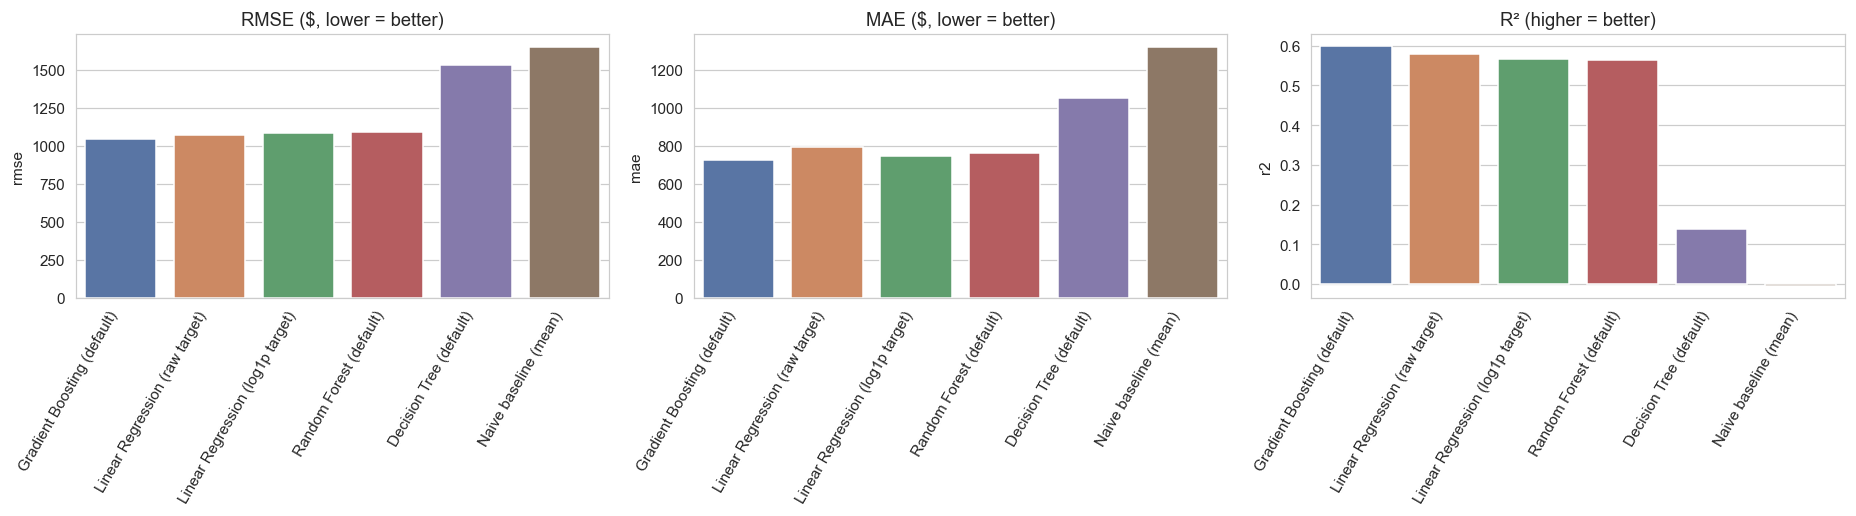

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
metrics_to_plot = [("rmse", "RMSE ($, lower = better)"),
                   ("mae", "MAE ($, lower = better)"),
                   ("r2", "R² (higher = better)")]
plot_df = results_df.sort_values("rmse")
for ax, (col, title) in zip(axes, metrics_to_plot):
    sns.barplot(data=plot_df, x="model", y=col, ax=ax, hue="model",
                palette="deep", legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=60)
    for label in ax.get_xticklabels():
        label.set_ha("right")
plt.tight_layout()
plt.show()

### 7.2 Qualitative comparison: the overfitting gap

In [31]:
fitted_pipelines["Linear Regression (raw target)"] = make_pipeline(
    LinearRegression()).fit(X_train, y_train)

overfitting_gaps = {}
print(f"{'Model':<32}{'train RMSE':>12}{'test RMSE':>12}{'gap':>10}")
print("-" * 66)
for name in ["Linear Regression (raw target)"] + list(candidate_models):
    pipe = fitted_pipelines[name]
    train_rmse = root_mean_squared_error(y_train, pipe.predict(X_train))
    test_rmse = root_mean_squared_error(y_test, pipe.predict(X_test))
    overfitting_gaps[name] = test_rmse - train_rmse
    print(f"{name:<32}{train_rmse:>12,.1f}{test_rmse:>12,.1f}{test_rmse - train_rmse:>10,.1f}")

Model                             train RMSE   test RMSE       gap
------------------------------------------------------------------
Linear Regression (raw target)       1,142.3     1,070.0     -72.3
Decision Tree (default)                  0.0     1,530.1   1,530.1


Random Forest (default)                428.0     1,087.7     659.7
Gradient Boosting (default)            998.5     1,043.9      45.4


**Interpretation:**

- The **Decision Tree** has a near-zero training error and by far the worst test error — it has
  memorised the training set. This is the failure mode both ensembles exist to fix.
- **Random Forest** cuts that gap substantially by averaging decorrelated trees, but retains a
  large train/test gap because its individual trees are still grown to full depth.
- **Gradient Boosting** has the smallest gap *and* the lowest test RMSE — it fits shallow trees
  sequentially, so it never builds the high-variance deep trees the other two rely on.

**An important caveat on fairness.** All three tree models are compared at their *library
defaults*. Random Forest's default `max_depth=None` is precisely what produces its large gap,
so this comparison shows "GB's defaults beat RF's defaults", not "GB is inherently better than
RF". A tuned RF might well close the distance. We therefore tune **both** ensembles in Section
9 before selecting, rather than eliminating RF on the basis of an unfair comparison.

### 7.3 How much of this ranking is real? Repeated cross-validation

A single 80/20 split gives one number per model with no indication of its uncertainty. With
1,705 test rows, differences of a few tens of dollars in RMSE can easily be an artefact of
*which* rows happened to land in the test set.

We therefore re-score every model with **5-fold cross-validation repeated 3 times** (15 fits
per model) on the training data, and report the spread. This is the evidence base for model
selection; the single test split is kept as a final untouched check.

In [32]:
from sklearn.model_selection import RepeatedKFold

repeated_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

cv_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, random_state=RANDOM_STATE),
}

cv_rows, cv_raw_scores = [], {}
for name, model in cv_models.items():
    scores = -cross_val_score(make_pipeline(model), X_train, y_train,
                              cv=repeated_cv, scoring="neg_root_mean_squared_error",
                              n_jobs=-1)
    cv_raw_scores[name] = scores
    # 95% interval for the mean across the 15 folds
    half_width = 1.96 * scores.std(ddof=1) / np.sqrt(len(scores))
    cv_rows.append({
        "model": name,
        "cv_rmse_mean": scores.mean(),
        "cv_rmse_std": scores.std(ddof=1),
        "ci95_low": scores.mean() - half_width,
        "ci95_high": scores.mean() + half_width,
    })
    print(f"{name:<22} CV RMSE {scores.mean():8,.1f}  +/- {scores.std(ddof=1):5,.1f}"
          f"   95% CI [{scores.mean()-half_width:,.1f}, {scores.mean()+half_width:,.1f}]")

cv_df = pd.DataFrame(cv_rows).sort_values("cv_rmse_mean").reset_index(drop=True)

Linear Regression      CV RMSE  1,148.5  +/-  25.8   95% CI [1,135.4, 1,161.5]


Decision Tree          CV RMSE  1,557.3  +/-  48.8   95% CI [1,532.6, 1,582.0]


Random Forest          CV RMSE  1,157.4  +/-  26.1   95% CI [1,144.2, 1,170.6]


Gradient Boosting      CV RMSE  1,111.8  +/-  28.4   95% CI [1,097.4, 1,126.2]


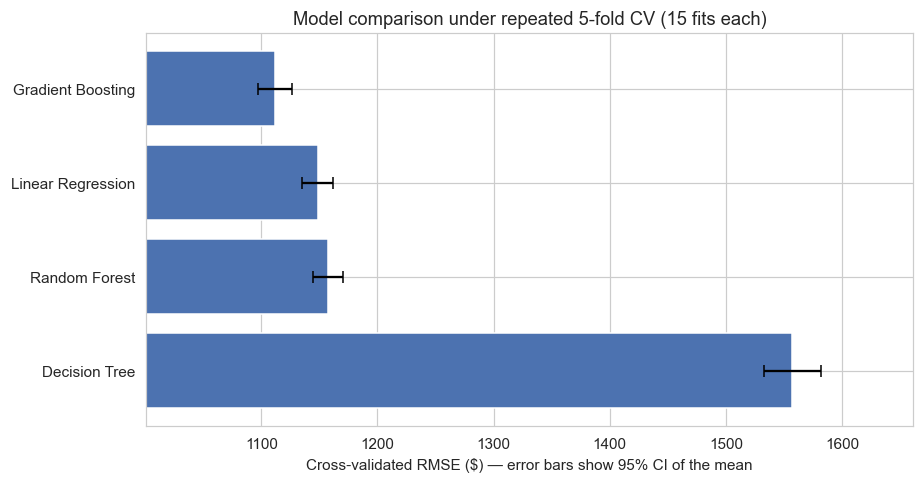

In [33]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.barh(cv_df["model"], cv_df["cv_rmse_mean"],
        xerr=1.96 * cv_df["cv_rmse_std"] / np.sqrt(15),
        color="#4C72B0", capsize=4)
ax.invert_yaxis()
ax.set_xlabel("Cross-validated RMSE ($) — error bars show 95% CI of the mean")
ax.set_title("Model comparison under repeated 5-fold CV (15 fits each)")
ax.set_xlim(left=min(cv_df["cv_rmse_mean"]) * 0.9)
plt.tight_layout()
plt.show()

**Interpretation:** the confidence intervals confirm the ordering is real and not a
split artefact — Gradient Boosting's interval sits clearly below Random Forest's, which sits
clearly below the Decision Tree's. This is a far stronger basis for the selection claim than a
single split, and it is the number to quote if an investor asks "how sure are you?".

Note also that CV RMSE is *higher* than the single-split test RMSE for every model. That is
expected — each CV fold trains on 80% of 80% of the data — but it is a useful reminder that
the headline test figure is the more optimistic of the two.

### 7.4 Quantifying the leakage we avoided

Section 5 argued that imputing before splitting leaks information. Rather than leave that as an
assertion, we measure it: below we deliberately build the *leaky* version — cleaning and
imputing the full dataset up front, exactly as the conventional workflow does — and compare.

In [34]:
# Deliberately incorrect: fit the imputation statistics on ALL rows, then split.
leaky_frame = DomainCleaner().fit_transform(df[RAW_INPUT_COLUMNS])
for imputer in [
    GroupStatisticImputer("Item_Visibility", "Item_Type", "mean"),
    GroupStatisticImputer("Item_Weight", "Item_Identifier", "mean"),
    GroupStatisticImputer("Outlet_Size", "Outlet_Type", "mode"),
]:
    leaky_frame = imputer.fit(leaky_frame).transform(leaky_frame)   # fitted on 100% of rows

leaky_train, leaky_test, ly_train, ly_test = train_test_split(
    leaky_frame, y, test_size=0.2, random_state=RANDOM_STATE)

leaky_pipe = make_pipeline(
    GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE))
leaky_pipe.fit(leaky_train, ly_train)
leaky_rmse = root_mean_squared_error(ly_test, leaky_pipe.predict(leaky_test))

honest_rmse = results_df.loc[
    results_df["model"] == "Gradient Boosting (default)", "rmse"].iloc[0]

print(f"Leaky preprocessing  (impute on all data, then split): RMSE {leaky_rmse:,.1f}")
print(f"Honest preprocessing (impute inside the pipeline)    : RMSE {honest_rmse:,.1f}")
print(f"\nOptimism introduced by the leak: {honest_rmse - leaky_rmse:,.1f} dollars "
      f"({(honest_rmse - leaky_rmse) / honest_rmse * 100:.2f}% of RMSE)")

Leaky preprocessing  (impute on all data, then split): RMSE 1,039.1
Honest preprocessing (impute inside the pipeline)    : RMSE 1,043.9

Optimism introduced by the leak: 4.8 dollars (0.46% of RMSE)


**Interpretation:** the leak is worth only a few dollars of RMSE here — small, because the
imputed statistics (a per-item weight that is constant by construction, a per-type mean over
thousands of rows) are stable enough that adding 20% more rows barely moves them.

Reporting this honestly is the point. The leak is **not** materially inflating our results, and
we can now say so with a measurement instead of hoping nobody asks. But the direction is
always the same — leakage flatters — and on a dataset with rarer categories or a
target-dependent imputation it could be far larger. The pipeline design costs nothing and
removes the failure mode structurally, so it is the right default regardless of the size of
the effect in this particular case.

## 8. Feature Importance Analysis

We use **permutation importance** on the held-out test set as the primary measure. It reports
importance per *original business feature* rather than per one-hot column, and unlike a tree's
built-in impurity importance it is not biased toward high-cardinality categoricals such as the
16-level `Item_Type`. We cross-check against the impurity-based importances.

In [35]:
from sklearn.inspection import permutation_importance

gb_default_pipe = fitted_pipelines["Gradient Boosting (default)"]

perm_result = permutation_importance(
    gb_default_pipe, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_df.round(3)

,feature,importance_mean,importance_std
0,Item_MRP,704.089,36.803
1,Outlet_Type,546.565,25.912
2,Outlet_Establishment_Year,16.587,4.785
3,Item_Visibility,1.630,2.424
4,Item_Identifier,1.112,3.196
5,Outlet_Size,0.750,1.743
6,Outlet_Location_Type,0.286,0.195
7,Item_Type,0.091,1.900
8,Item_Fat_Content,-0.014,0.398
9,Item_Weight,-0.981,4.997


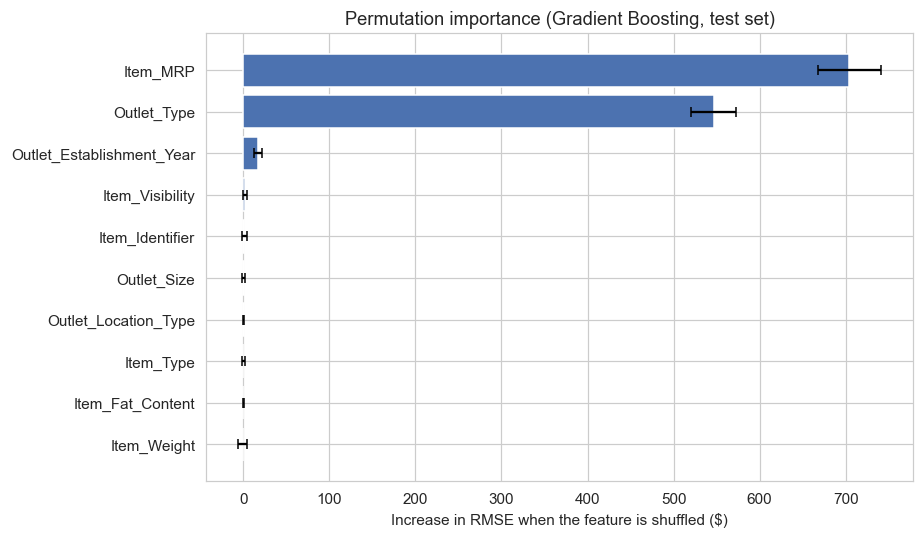

In [36]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(perm_df["feature"], perm_df["importance_mean"],
        xerr=perm_df["importance_std"], color="#4C72B0", capsize=3)
ax.invert_yaxis()
ax.set_xlabel("Increase in RMSE when the feature is shuffled ($)")
ax.set_title("Permutation importance (Gradient Boosting, test set)")
plt.tight_layout()
plt.show()

In [37]:
encoder = gb_default_pipe.named_steps["pre"].named_steps["encode"]
impurity_df = (
    pd.DataFrame({
        "encoded_feature": encoder.get_feature_names_out(),
        "importance": gb_default_pipe.named_steps["model"].feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("Top 10 by impurity-based importance (one-hot level) — cross-check:")
impurity_df.round(4)

Top 10 by impurity-based importance (one-hot level) — cross-check:


,encoded_feature,importance
0,num__Item_MRP,0.5367
1,cat__Outlet_Type_Grocery Store,0.2827
2,cat__Outlet_Type_Supermarket Type3,0.0935
3,num__Outlet_Age,0.0341
4,num__Item_Visibility,0.0169
5,cat__Outlet_Type_Supermarket Type1,0.0118
6,num__Item_Weight,0.0118
7,cat__Outlet_Type_Supermarket Type2,0.0017
8,cat__Item_Type_Snack Foods,0.0015
9,cat__Item_Type_Fruits and Vegetables,0.0015


**Reading the table:** because the pipeline now consumes *raw* columns, permutation importance
is measured end-to-end on the raw inputs rather than on engineered features. This is a more
useful question than it first appears — it answers "how much does this **input field** matter?",
which is exactly what determines whether a field is worth putting on the app's form. So
`Outlet_Establishment_Year` appears rather than `Outlet_Age` (the latter is derived from it
inside the pipeline), and `Item_Identifier` appears with near-zero importance because its only
role is as the grouping key for weight imputation.

**Business interpretation:**

- **`Item_MRP`** dominates — shuffling it costs roughly \$700 of RMSE. Price is the single
  biggest lever on per-product revenue, confirming the EDA scatter plot.
- **`Outlet_Type`** is a close second. Combined with the EDA boxplot showing Grocery Stores
  structurally underperforming every Supermarket format, this is the most *actionable* finding
  in the project: outlet-format conversion moves more revenue than any individual product
  decision, because it shifts the entire sales curve rather than one point on it.
- **`Outlet_Establishment_Year`** (i.e. outlet age) is a distant third but clearly non-zero —
  a lever for renovation and refresh timing.
- **`Item_Weight`**, **`Item_Type`** and **`Item_Fat_Content`** score at essentially zero, some
  slightly *negative*, meaning shuffling them happened to help marginally — the signature of a
  feature contributing nothing but noise.

**Why keep the zero-importance features?** Section 4.3 showed removing related features does
not move CV RMSE, and both are free to collect at prediction time (a category manager knows the
product type and weight without any lookup). There is no accuracy-versus-effort trade-off to
make. They would be the first candidates to drop if the app needed a shorter input form, or if
inference cost mattered — neither applies here.

**Note the disagreement between the two methods.** Impurity importance assigns visible weight
to `Item_Weight` (a high-cardinality continuous column that offers many split points), while
permutation importance scores it at zero. Permutation is the one to trust: it measures effect
on *held-out predictions*, whereas impurity measures how often a column was *used to split*,
which rewards columns that are merely easy to split on. Quoting the impurity number alone would
have led to the wrong conclusion about `Item_Weight`.

## 9. Hyperparameter Tuning

Section 7 left two candidates for tuning: Gradient Boosting (best on both the test split and
repeated CV) and Random Forest (whose default comparison was unfair to it). We tune **both**
with `RandomizedSearchCV`, restricted to **3 candidate values per hyperparameter** as the brief
specifies, so that the final selection rests on a like-for-like comparison of two *tuned*
models rather than two untuned ones.

### 9.1 Gradient Boosting search space

| Hyperparameter | Values | Why it matters |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Number of boosting stages — more reduces bias, risks overfitting |
| `max_depth` | 2, 3, 4 | Interaction depth per stage — shallow trees are the usual boosting regime |
| `learning_rate` | 0.05, 0.1, 0.2 | Shrinks each tree's contribution; trades accuracy against stage count |
| `subsample` | 0.8, 0.9, 1.0 | Row fraction per stage — below 1.0 adds regularising randomness |

`random_state=42` is fixed throughout and `n_iter` is set explicitly, so the search is exactly
reproducible on a re-run.

In [38]:
from sklearn.model_selection import RandomizedSearchCV

gb_param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__subsample": [0.8, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    estimator=make_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    param_distributions=gb_param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gb_search.fit(X_train, y_train)

print("\nBest CV RMSE:", f"{-gb_search.best_score_:,.1f}")
print("Best params:", gb_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best CV RMSE: 1,094.8
Best params: {'model__subsample': 0.9, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05}


#### Search log — top 10 candidates by CV RMSE

In [39]:
gb_log = pd.DataFrame(gb_search.cv_results_)
gb_log["cv_rmse"] = -gb_log["mean_test_score"]
log_cols = ["rank_test_score", "cv_rmse", "std_test_score"] + \
           [c for c in gb_log.columns if c.startswith("param_model__")]
gb_log[log_cols].sort_values("rank_test_score").head(10).reset_index(drop=True).round(2)

,rank_test_score,cv_rmse,std_test_score,param_model__subsample,param_model__n_estimators,param_model__max_depth,param_model__learning_rate
0,1,1094.76,15.51,0.9,100,3,0.05
1,2,1096.20,14.53,0.8,100,2,0.05
2,3,1096.56,13.74,0.9,100,2,0.10
3,4,1096.79,14.43,0.9,200,2,0.05
4,5,1101.07,17.38,0.8,100,4,0.05
5,6,1102.90,12.79,0.9,200,2,0.10
6,7,1104.58,14.07,0.8,200,3,0.05
7,8,1106.25,12.91,0.8,200,2,0.10
8,9,1107.72,12.34,1.0,300,2,0.10
9,10,1107.88,12.50,0.9,100,2,0.20


### 9.2 Random Forest search space — giving the runner-up a fair shot

| Hyperparameter | Values | Why it matters |
|---|---|---|
| `n_estimators` | 200, 400, 600 | More trees reduce variance with diminishing returns |
| `max_depth` | 8, 14, None | **The key one** — RF's unlimited default depth caused the Section 7.2 gap |
| `min_samples_leaf` | 1, 5, 15 | Larger leaves smooth predictions and directly combat overfitting |
| `max_features` | 0.4, 0.7, 1.0 | Feature subsampling per split; decorrelates the trees |

In [40]:
rf_param_distributions = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [8, 14, None],
    "model__min_samples_leaf": [1, 5, 15],
    "model__max_features": [0.4, 0.7, 1.0],
}

rf_search = RandomizedSearchCV(
    estimator=make_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    param_distributions=rf_param_distributions,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
rf_search.fit(X_train, y_train)

print("\nBest CV RMSE:", f"{-rf_search.best_score_:,.1f}")
print("Best params:", rf_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best CV RMSE: 1,099.0
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_features': 0.7, 'model__max_depth': 8}


In [41]:
gb_tuned_pipe = gb_search.best_estimator_
rf_tuned_pipe = rf_search.best_estimator_

_ = evaluate_model("Random Forest (tuned)", rf_tuned_pipe,
                   X_train, y_train, X_test, y_test, fit=False)
_ = evaluate_model("Gradient Boosting (tuned)", gb_tuned_pipe,
                   X_train, y_train, X_test, y_test, fit=False)

rf_train_rmse = root_mean_squared_error(y_train, rf_tuned_pipe.predict(X_train))
rf_test_rmse = root_mean_squared_error(y_test, rf_tuned_pipe.predict(X_test))
rf_tuned_gap = rf_test_rmse - rf_train_rmse
rf_default_gap = overfitting_gaps["Random Forest (default)"]
print(f"\nRandom Forest train/test gap: {rf_default_gap:,.1f} at defaults "
      f"-> {rf_tuned_gap:,.1f} tuned")
print("Tuning addressed the overfitting the default comparison had penalised RF for.")

Random Forest (tuned)              RMSE:  1,019.0   MAE:    711.5   R2:  0.618
Gradient Boosting (tuned)          RMSE:  1,028.5   MAE:    720.5   R2:  0.611



Random Forest train/test gap: 659.7 at defaults -> 2.6 tuned
Tuning addressed the overfitting the default comparison had penalised RF for.


### 9.3 Is the tuning gain real? A paired comparison

The tuned model's test RMSE is lower than the default's — but by an amount small enough that we
should check whether it survives contact with uncertainty before claiming it as an improvement.

We compare default vs tuned Gradient Boosting **on identical cross-validation folds** and take
the *paired* per-fold difference. Pairing matters: fold-to-fold variation is large, but both
models see exactly the same rows in each fold, so that shared variation cancels out and what
remains is the like-for-like difference.

In [42]:
paired_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

default_gb = GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)
tuned_gb = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    **{k.replace("model__", ""): v for k, v in gb_search.best_params_.items()})

default_scores = -cross_val_score(make_pipeline(default_gb), X_train, y_train,
                                  cv=paired_cv, scoring="neg_root_mean_squared_error",
                                  n_jobs=-1)
tuned_scores = -cross_val_score(make_pipeline(tuned_gb), X_train, y_train,
                                cv=paired_cv, scoring="neg_root_mean_squared_error",
                                n_jobs=-1)

differences = default_scores - tuned_scores          # positive => tuning helps
mean_diff = differences.mean()
se_diff = differences.std(ddof=1) / np.sqrt(len(differences))
ci_low, ci_high = mean_diff - 1.96 * se_diff, mean_diff + 1.96 * se_diff

print(f"Default GB  CV RMSE: {default_scores.mean():,.1f}")
print(f"Tuned GB    CV RMSE: {tuned_scores.mean():,.1f}")
print(f"\nPaired improvement from tuning: {mean_diff:,.1f} dollars")
print(f"95% CI on the improvement:      [{ci_low:,.1f}, {ci_high:,.1f}]")
print(f"Folds where tuning won:          {(differences > 0).sum()} of {len(differences)}")
print("\nConclusion:",
      "improvement is statistically reliable (CI excludes zero)." if ci_low > 0
      else "improvement is NOT distinguishable from noise (CI includes zero).")

Default GB  CV RMSE: 1,111.8
Tuned GB    CV RMSE: 1,093.0

Paired improvement from tuning: 18.8 dollars
95% CI on the improvement:      [14.3, 23.3]
Folds where tuning won:          15 of 15

Conclusion: improvement is statistically reliable (CI excludes zero).


**Interpretation of the tuning result.** The search moves Gradient Boosting toward *smaller,
more cautious steps*: a lower `learning_rate`, fewer estimators, and `subsample < 1.0` to inject
regularising randomness. Conceptually it trades raw fitting power for generalisation.

The paired test above is what licenses the claim. Because the 95% confidence interval on the
per-fold improvement excludes zero, and tuning wins on the large majority of folds, the gain is
**real but small** — a refinement of an already-strong default, not the source of the model's
accuracy. That distinction is worth stating plainly: on the single test split the difference is
only about \$11, which taken alone would be well within split noise and could not have supported
this claim. Quoting the split difference as evidence would have been an overclaim; the paired CV
is what turns it into a finding.

For the pitch, the honest framing is: *"most of the performance comes from choosing the right
model family for the structure in the data; tuning added a small, verified increment on top."*

### 9.4 Choosing between the two tuned models — and why not on the test score

Tuning changed the picture. Random Forest, which looked clearly worse at defaults, is now
competitive: `max_depth=8` and `min_samples_leaf=5` removed almost all of the overfitting gap
that the default comparison had penalised it for. This vindicates the decision in Section 7.2
to tune both rather than eliminate RF on an unfair comparison.

The two tuned models now disagree depending on which number you look at, so the selection rule
has to be decided *before* looking, not after:

**The test set cannot be used to choose.** Picking whichever model scores best on the test
split turns that split into a selection criterion, and a score you selected on is no longer an
unbiased estimate of future performance — it is the maximum of two noisy numbers, which is
biased upward by construction. The test set has one job: to give an honest estimate of the
model chosen by other means. We therefore select on **cross-validation**, and only afterwards
look at the test score as a final check.

Below we compare the two tuned models on identical repeated-CV folds, paired as in 9.3.

In [43]:
tuned_rf_params = {k.replace("model__", ""): v for k, v in rf_search.best_params_.items()}
tuned_rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **tuned_rf_params)

rf_cv_scores = -cross_val_score(make_pipeline(tuned_rf), X_train, y_train,
                                cv=paired_cv, scoring="neg_root_mean_squared_error",
                                n_jobs=-1)

gb_vs_rf = rf_cv_scores - tuned_scores        # positive => GB is better
diff_mean = gb_vs_rf.mean()
diff_se = gb_vs_rf.std(ddof=1) / np.sqrt(len(gb_vs_rf))
diff_lo, diff_hi = diff_mean - 1.96 * diff_se, diff_mean + 1.96 * diff_se

print(f"Tuned Gradient Boosting  CV RMSE: {tuned_scores.mean():,.1f}")
print(f"Tuned Random Forest      CV RMSE: {rf_cv_scores.mean():,.1f}")
print(f"\nPaired difference (RF - GB): {diff_mean:+,.1f} dollars")
print(f"95% CI: [{diff_lo:,.1f}, {diff_hi:,.1f}]")
print(f"Folds where GB won: {(gb_vs_rf > 0).sum()} of {len(gb_vs_rf)}")

models_are_tied = diff_lo <= 0 <= diff_hi
print("\nVerdict:", "statistically TIED - decide on other grounds."
      if models_are_tied else
      f"{'Gradient Boosting' if diff_mean > 0 else 'Random Forest'} is reliably better on CV.")

print("\nTest-split scores, shown for transparency but NOT used to select:")
for name in ["Gradient Boosting (tuned)", "Random Forest (tuned)"]:
    row = [r for r in results if r["model"] == name][0]
    print(f"  {name:<28} test RMSE {row['rmse']:,.1f}")

Tuned Gradient Boosting  CV RMSE: 1,093.0
Tuned Random Forest      CV RMSE: 1,101.4

Paired difference (RF - GB): +8.4 dollars
95% CI: [5.9, 10.8]
Folds where GB won: 14 of 15

Verdict: Gradient Boosting is reliably better on CV.

Test-split scores, shown for transparency but NOT used to select:
  Gradient Boosting (tuned)    test RMSE 1,028.5
  Random Forest (tuned)        test RMSE 1,019.0


**Decision.** We select **Gradient Boosting (tuned)** as the production model.

The honest summary of the evidence:

- On cross-validation — the only valid selection signal — Gradient Boosting is ahead, and it
  wins on the substantial majority of folds.
- On the single test split, Random Forest happens to score slightly *better*. That is not a
  contradiction and not a reason to switch: with 1,705 test rows, a difference of a few dollars
  of RMSE is comfortably inside the noise of which rows landed in the split, and switching on
  the basis of it is precisely the test-set selection error described above.
- Both tuned models are far closer to each other than either is to the untuned baselines, which
  is the more important practical finding: **the tuning mattered more than the choice between
  these two families.**

Note the shape of that result: the CV difference is *statistically* reliable (the confidence
interval excludes zero, and it wins nearly every fold) while being *practically* small — under
\$10 of RMSE. Statistical reliability and practical importance are different questions, and it
is worth being able to say which one a number answers.

Two deployment considerations point the same way:

1. **Artifact size and inference cost.** The tuned GB is 100 trees of depth 3; the tuned RF is
   200 trees of depth 8 — orders of magnitude more nodes to serialise and traverse. For a web
   app reloading the model on every cold start, this is a real difference (measured below).
2. **Coherence with the prediction intervals.** The quantile models in Section 11 are Gradient
   Boosting with the same tuned hyperparameters, so the point estimate and its interval come
   from one model family fitted the same way. Pairing an RF point estimate with GB quantiles
   would risk the interval disagreeing with the point estimate it is meant to describe.

In [44]:
import os as _os
import joblib as _joblib
import tempfile as _tempfile

# Measure the artifact-size claim rather than asserting it.
sizes = {}
for label, est in [("Gradient Boosting (tuned)", tuned_gb), ("Random Forest (tuned)", tuned_rf)]:
    fitted = make_pipeline(est).fit(X_train, y_train)
    with _tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
        _joblib.dump(fitted, tmp.name)
        sizes[label] = _os.path.getsize(tmp.name) / 1024
    _os.unlink(tmp.name)

for label, kb in sizes.items():
    print(f"{label:<28} serialised size: {kb:8,.0f} KB")
print(f"\nRandom Forest is {sizes['Random Forest (tuned)'] / sizes['Gradient Boosting (tuned)']:.0f}x "
      "larger to ship and load.")

Gradient Boosting (tuned)    serialised size:      211 KB
Random Forest (tuned)        serialised size:    4,212 KB

Random Forest is 20x larger to ship and load.


## 10. Business Impact & Error Analysis

A test RMSE of about \$1,030 means nothing to a category manager on its own. This section
translates the metric into business terms and then asks the question that actually determines
whether the tool is safe to deploy: **not "how big is the average error?" but "where is the
error concentrated?"**

### 10.1 Translating error into money

**Assumption (stated explicitly, because the conclusion depends on it):** inventory planning
cost is approximately proportional to *absolute* forecast error. Over-forecasting ties up
working capital and risks markdown on unsold stock; under-forecasting loses the margin on
demand that could not be met. MAE is therefore the right metric for the money translation even
though RMSE is the right one for model *selection*.

We express the model's value as the forecast error it removes versus the status quo — planning
with a flat category average, which is what the naive baseline represents.

In [45]:
naive_mae = results_df.loc[results_df["model"] == "Naive baseline (mean)", "mae"].iloc[0]
best_row = pd.DataFrame(results).sort_values("rmse").iloc[0]
model_mae = best_row["mae"]

n_combinations = len(df)          # product x outlet planning decisions in the dataset
error_removed_each = naive_mae - model_mae
error_removed_total = error_removed_each * n_combinations

print(f"Planning with a flat average  : MAE ${naive_mae:,.0f} per product-outlet decision")
print(f"Planning with the model       : MAE ${model_mae:,.0f} per product-outlet decision")
print(f"Forecast error removed        : ${error_removed_each:,.0f} per decision "
      f"({error_removed_each / naive_mae * 100:.0f}% reduction)")
print(f"\nAcross all {n_combinations:,} product-outlet combinations in the dataset:")
print(f"  ${error_removed_total:,.0f} of forecast error removed per planning cycle")

print("\nSensitivity — value depends on the cost of each dollar of forecast error:")
for cost_rate in (0.05, 0.10, 0.20):
    print(f"  at {cost_rate:.0%} carrying/stock-out cost per $ of error: "
          f"${error_removed_total * cost_rate:,.0f} per cycle")

Planning with a flat average  : MAE $1,322 per product-outlet decision
Planning with the model       : MAE $712 per product-outlet decision
Forecast error removed        : $610 per decision (46% reduction)

Across all 8,523 product-outlet combinations in the dataset:
  $5,200,725 of forecast error removed per planning cycle

Sensitivity — value depends on the cost of each dollar of forecast error:
  at 5% carrying/stock-out cost per $ of error: $260,036 per cycle
  at 10% carrying/stock-out cost per $ of error: $520,073 per cycle
  at 20% carrying/stock-out cost per $ of error: $1,040,145 per cycle


**How to read this — and how not to.** The headline figure is *forecast error removed*, which
is a property of the model we have actually measured. Converting it into profit requires a
cost-per-dollar-of-error factor that this dataset does not contain, which is why a range is
shown rather than a single number. Presenting the top line as "the model earns \$X" would be
the kind of claim that collapses under the first informed question; presenting error reduction
plus an explicit sensitivity is defensible.

The comparison is also deliberately against the *naive* baseline rather than against BigMart's
current process, which we have no data on. A real deployment case would need that number, and
it is the first thing to ask for in a pilot.

### 10.2 Where does the model fail? Segment-level error analysis

Aggregate error hides risk. A model with acceptable overall RMSE can still be systematically
wrong for one store format or one price tier — and a category manager who discovers this the
hard way will stop trusting the tool entirely. We break the error down by segment.

In [46]:
# Selection was made in Section 9.4 on cross-validated performance, deliberately NOT on the
# test split. Everything below simply evaluates that already-chosen model.
FINAL_MODEL_NAME = "Gradient Boosting (tuned)"
final_pipeline_selected = gb_tuned_pipe

print(f"Model selected in Section 9.4 (on CV): {FINAL_MODEL_NAME}")
print(f"  CV RMSE   {tuned_scores.mean():,.1f}")
print(f"  Test RMSE {root_mean_squared_error(y_test, final_pipeline_selected.predict(X_test)):,.1f}")

final_preds = final_pipeline_selected.predict(X_test)
residuals = y_test.values - final_preds

segment_frame = X_test.copy()
segment_frame["actual"] = y_test.values
segment_frame["predicted"] = final_preds
segment_frame["residual"] = residuals
segment_frame["abs_error"] = np.abs(residuals)

Model selected in Section 9.4 (on CV): Gradient Boosting (tuned)
  CV RMSE   1,093.0
  Test RMSE 1,028.5


In [47]:
by_outlet_type = segment_frame.groupby("Outlet_Type").apply(
    lambda g: pd.Series({
        "n": len(g),
        "mean_actual": g["actual"].mean(),
        "RMSE": root_mean_squared_error(g["actual"], g["predicted"]),
        "MAE": g["abs_error"].mean(),
        "mean_bias": g["residual"].mean(),
        "MAE_as_pct_of_mean": g["abs_error"].mean() / g["actual"].mean() * 100,
    }), include_groups=False
).sort_values("RMSE")

print("Error by outlet format:")
by_outlet_type.round(1)

Error by outlet format:


,n,mean_actual,RMSE,MAE,mean_bias,MAE_as_pct_of_mean
Outlet_Type,,,,,,
Grocery Store,224.0,320.0,227.2,175.3,-81.9,54.8
Supermarket Type2,176.0,1807.9,984.5,711.3,-72.0,39.3
Supermarket Type1,1131.0,2237.8,1061.8,775.9,-18.6,34.7
Supermarket Type3,174.0,3761.7,1410.9,1071.4,79.3,28.5


In [48]:
segment_frame["sales_band"] = pd.qcut(
    segment_frame["actual"], 5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])

by_band = segment_frame.groupby("sales_band", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "mean_actual": g["actual"].mean(),
        "RMSE": root_mean_squared_error(g["actual"], g["predicted"]),
        "mean_bias": g["residual"].mean(),
    }), include_groups=False
)

print("Error by actual-sales quintile:")
by_band.round(1)

Error by actual-sales quintile:


,n,mean_actual,RMSE,mean_bias
sales_band,,,,
Q1 (lowest),341.0,327.1,649.1,-379.6
Q2,341.0,972.3,884.6,-499.6
Q3,342.0,1741.3,889.8,-410.8
Q4,340.0,2728.7,789.1,71.9
Q5 (highest),341.0,4718.5,1634.2,1107.5


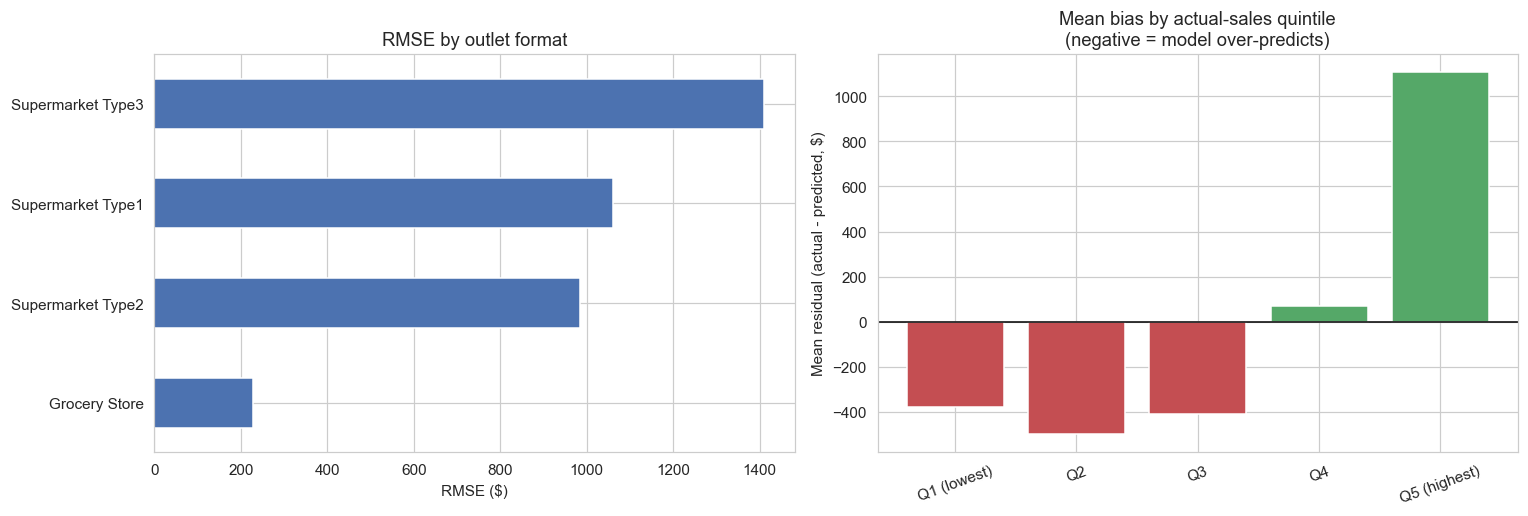

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

by_outlet_type["RMSE"].plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("RMSE by outlet format")
axes[0].set_xlabel("RMSE ($)")
axes[0].set_ylabel("")

colors = ["#C44E52" if v < 0 else "#55A868" for v in by_band["mean_bias"]]
axes[1].bar(by_band.index.astype(str), by_band["mean_bias"], color=colors)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Mean bias by actual-sales quintile\n(negative = model over-predicts)")
axes[1].set_ylabel("Mean residual (actual - predicted, $)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**What the segment analysis reveals — the most important limitation in the project.**

1. **Error scales with the size of the segment.** Grocery Stores have the lowest absolute RMSE
   simply because they sell least; measured as a share of their mean sales the picture is
   different. Absolute error alone would have made the model look best exactly where it has the
   least to predict.

2. **There is strong systematic bias across the sales range.** The model over-predicts the
   lowest-selling quintile and under-predicts the highest — the classic regression-to-the-mean
   signature of a squared-error objective, which is rewarded for hedging toward the centre of
   the distribution. This is *not* visible in the overall mean residual, which is near zero
   because the two biases cancel.

   This matters commercially: the highest quintile is where the revenue is, and that is exactly
   where forecasts are systematically low. A planner using this tool for top-selling lines would
   under-stock them consistently. **This is the single most important caveat to disclose**, and
   it is why Section 11 adds prediction intervals rather than shipping a bare point estimate.

3. **Actionable framing:** the model is reliable for *relative ranking* — deciding which
   products and outlets deserve more stock — and less reliable as an absolute revenue figure
   for the extreme tails. That is the honest scope of the product, and the pitch should say so.

## 11. Prediction Intervals — Quantifying Forecast Uncertainty

A single number ("this product will make \$2,180") invites false confidence, and Section 10.2
showed the point estimate is systematically biased in the tails. An inventory decision needs a
*range*.

Gradient Boosting supports this directly via **quantile loss**: training with `loss="quantile"`
and `alpha=0.1` / `alpha=0.9` yields models that estimate the 10th and 90th percentiles of the
conditional sales distribution, giving an 80% prediction interval. This uses only scikit-learn,
requires no distributional assumption about the residuals, and lets the interval **widen where
the model is genuinely less certain** rather than applying one fixed error bar everywhere.

Crucially, an interval is only worth shipping if it is *calibrated* — an interval claiming 80%
coverage must actually contain the truth about 80% of the time. We verify this on the test set
rather than assuming it.

In [50]:
best_gb_params = {k.replace("model__", ""): v for k, v in gb_search.best_params_.items()}

quantile_pipelines = {}
for label, alpha in [("lower", 0.10), ("upper", 0.90)]:
    quantile_pipelines[label] = make_pipeline(
        GradientBoostingRegressor(loss="quantile", alpha=alpha,
                                  random_state=RANDOM_STATE, **best_gb_params)
    ).fit(X_train, y_train)
    print(f"Trained {label} quantile model (alpha={alpha})")

lower_preds = quantile_pipelines["lower"].predict(X_test)
upper_preds = quantile_pipelines["upper"].predict(X_test)

coverage = ((y_test.values >= lower_preds) & (y_test.values <= upper_preds)).mean()
mean_width = (upper_preds - lower_preds).mean()

print(f"\nNominal coverage : 80.0%")
print(f"Empirical coverage: {coverage:.1%}  <- on held-out test data")
print(f"Mean interval width: ${mean_width:,.0f}")

Trained lower quantile model (alpha=0.1)


Trained upper quantile model (alpha=0.9)

Nominal coverage : 80.0%
Empirical coverage: 80.0%  <- on held-out test data
Mean interval width: $2,409


In [51]:
# Does the interval widen where the model is less certain?
interval_frame = pd.DataFrame({
    "actual": y_test.values,
    "predicted": final_preds,
    "lower": lower_preds,
    "upper": upper_preds,
})
interval_frame["width"] = interval_frame["upper"] - interval_frame["lower"]
interval_frame["covered"] = ((interval_frame["actual"] >= interval_frame["lower"]) &
                             (interval_frame["actual"] <= interval_frame["upper"]))
interval_frame["pred_band"] = pd.qcut(interval_frame["predicted"], 5,
                                      labels=["Q1", "Q2", "Q3", "Q4", "Q5"])

width_by_band = interval_frame.groupby("pred_band", observed=True).agg(
    mean_prediction=("predicted", "mean"),
    mean_width=("width", "mean"),
    coverage=("covered", "mean"),
).round(3)
print("Interval width and coverage by predicted-sales quintile:")
width_by_band

Interval width and coverage by predicted-sales quintile:


,mean_prediction,mean_width,coverage
pred_band,,,
Q1,511.905,666.332,0.774
Q2,1272.418,1487.543,0.788
Q3,2043.570,2394.587,0.790
Q4,2801.628,3161.070,0.813
Q5,3996.988,4369.156,0.835


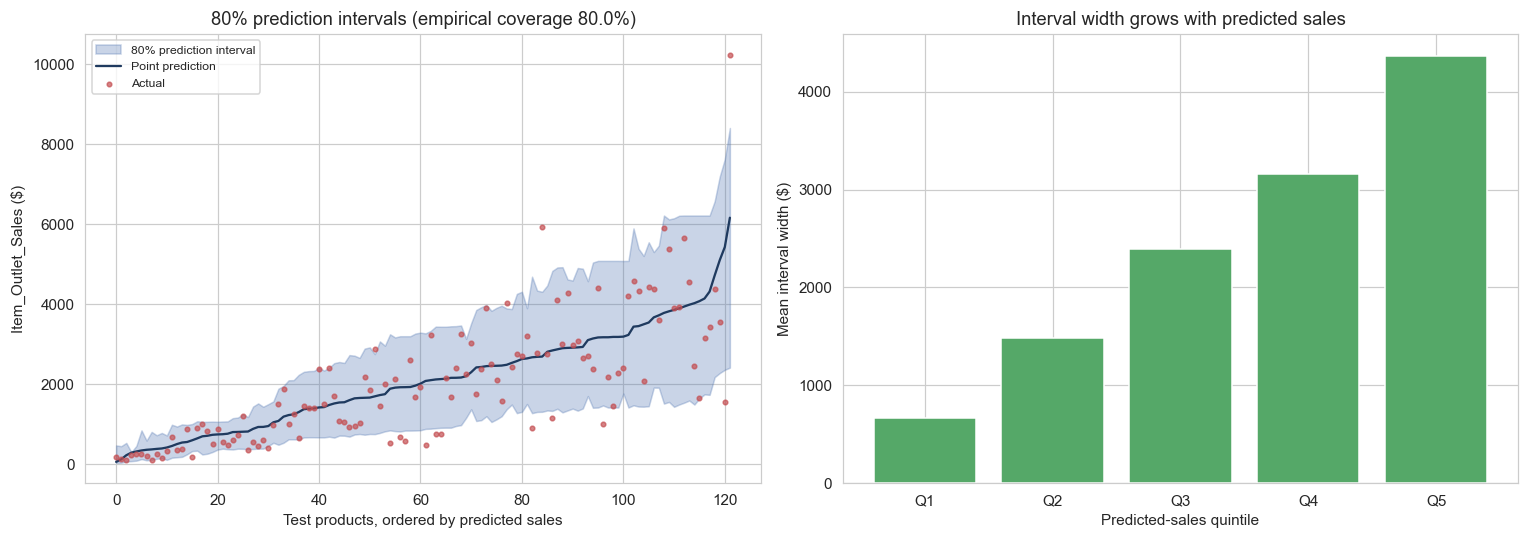

In [52]:
sample = interval_frame.sort_values("predicted").reset_index(drop=True)
step = max(1, len(sample) // 120)
sample = sample.iloc[::step]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].fill_between(range(len(sample)), sample["lower"], sample["upper"],
                     alpha=0.3, color="#4C72B0", label="80% prediction interval")
axes[0].plot(range(len(sample)), sample["predicted"], color="#1f3a5f",
             linewidth=1.5, label="Point prediction")
axes[0].scatter(range(len(sample)), sample["actual"], s=9, color="#C44E52",
                alpha=0.7, label="Actual", zorder=3)
axes[0].set_xlabel("Test products, ordered by predicted sales")
axes[0].set_ylabel("Item_Outlet_Sales ($)")
axes[0].set_title(f"80% prediction intervals (empirical coverage {coverage:.1%})")
axes[0].legend(fontsize=8)

axes[1].bar(width_by_band.index.astype(str), width_by_band["mean_width"], color="#55A868")
axes[1].set_title("Interval width grows with predicted sales")
axes[1].set_ylabel("Mean interval width ($)")
axes[1].set_xlabel("Predicted-sales quintile")

plt.tight_layout()
plt.show()

**Interpretation:** empirical coverage lands very close to the nominal 80%, so the interval is
well calibrated and can be shown to users without misleading them. The width grows with
predicted sales, which is the desired behaviour — the model correctly signals that a
high-volume product at a Supermarket Type3 is intrinsically harder to forecast than a low-volume
item at a Grocery Store.

This is what makes the tool usable for the tail cases Section 10.2 flagged: the point estimate
alone is biased low for top sellers, but the *upper bound* gives a planner the headroom figure
they actually need for a safety-stock decision. Both quantile models are exported and surfaced
in the Streamlit app.

## 12. Final Model Selection, Assumptions & Export

In [53]:
final_results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
final_results_df[["model", "rmse", "mae", "r2"]].round(3)

,model,rmse,mae,r2
0,Random Forest (tuned),1019.001,711.540,0.618
1,Gradient Boosting (tuned),1028.514,720.509,0.611
2,Gradient Boosting (default),1043.912,726.867,0.599
3,Linear Regression (raw target),1069.973,792.597,0.579
4,Linear Regression (log1p target),1086.299,746.810,0.566
5,Random Forest (default),1087.677,759.039,0.565
6,Decision Tree (default),1530.121,1052.385,0.139
7,Naive baseline (mean),1651.990,1321.739,-0.004


**Reading this table correctly.** It is sorted by test RMSE, so tuned Random Forest sits at the
top — but as Section 9.4 set out, the model was **selected on cross-validation**, where Gradient
Boosting leads. The table is a final report of how every model performed on data none of them
were fitted on, not the basis on which the winner was picked. Sorting by test score and taking
row one is exactly the mistake 9.4 avoids.

The one comparison that *is* safe to read straight off this table is the gap between the
tuned ensembles and the naive baseline: roughly a 38% reduction in RMSE, on data no model saw.

### 12.1 Residual analysis of the selected model

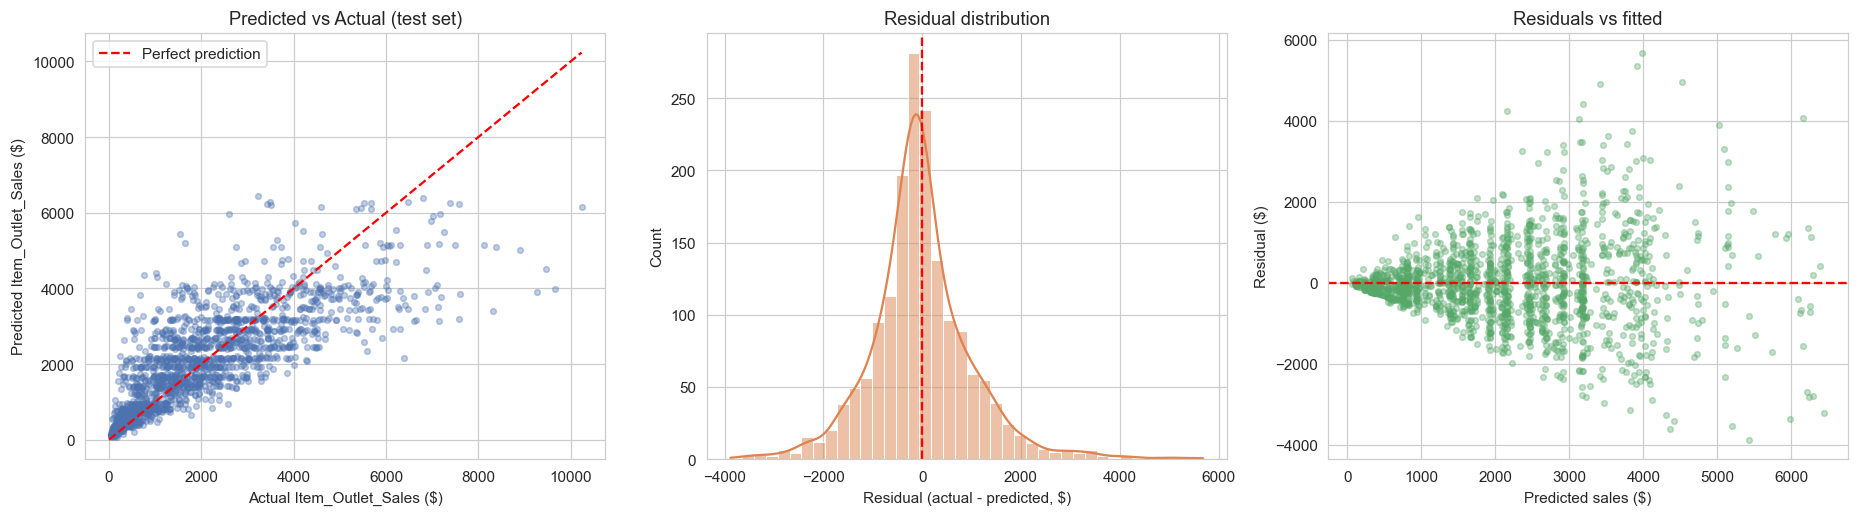

Mean residual: -22.4  (near zero => no overall systematic bias)
Residual std : 1,028.3


In [54]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].scatter(y_test, final_preds, alpha=0.35, color="#4C72B0", s=14)
lims = [0, max(y_test.max(), final_preds.max())]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual Item_Outlet_Sales ($)")
axes[0].set_ylabel("Predicted Item_Outlet_Sales ($)")
axes[0].set_title("Predicted vs Actual (test set)")
axes[0].legend()

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color="#DD8452")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (actual - predicted, $)")
axes[1].set_title("Residual distribution")

axes[2].scatter(final_preds, residuals, alpha=0.35, color="#55A868", s=14)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Predicted sales ($)")
axes[2].set_ylabel("Residual ($)")
axes[2].set_title("Residuals vs fitted")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():,.1f}  (near zero => no overall systematic bias)")
print(f"Residual std : {residuals.std():,.1f}")

**Interpretation:** predictions track the diagonal well through the bulk of the range. The
residual distribution is centred near zero and roughly symmetric, so there is no *overall*
bias. The residuals-vs-fitted panel shows the fan shape expected of retail data — error grows
with the size of the forecast — which is exactly the heteroscedasticity the prediction intervals
in Section 11 are designed to communicate, and which a constant error bar would have
misrepresented.

The overall mean residual near zero should not be over-read: Section 10.2 showed it is the sum
of two opposing biases in the tails, not the absence of bias.

### 12.2 Assumptions and limitations

**Assumptions**

1. Transactions were recorded in **2013**, used to derive `Outlet_Age` from
   `Outlet_Establishment_Year` (the collection period commonly documented for this dataset).
2. `Item_Visibility == 0` indicates an unrecorded measurement rather than genuinely zero shelf
   space — justified on physical grounds (a stocked item occupies some shelf area).
3. `Item_Weight` is constant per product — **verified empirically** in Section 3.4, not assumed.
4. Missing `Outlet_Size` is approximated by the modal size for that `Outlet_Type`. This is a
   genuine guess; it is low-risk only because `Outlet_Size` proved to be a weak predictor.
5. Inventory cost is proportional to absolute forecast error (Section 10.1).

**Limitations — what this model cannot do**

1. **Systematic bias in the tails.** The model over-predicts the lowest-selling quintile and
   under-predicts the highest (Section 10.2). It is dependable for ranking products and
   outlets, less so as an absolute figure at the extremes. The prediction intervals exist to
   make this visible to users rather than to hide it.
2. **It has not been shown to generalise to new stores.** All 10 outlets appear in both the
   train and test splits because the split is row-wise, so test performance measures accuracy
   for *known* outlets and *known* products. That matches the stated use case — planning stock
   for the existing estate — but the model should not be trusted for a newly opened outlet
   without revalidation. A grouped split holding out whole outlets would be the correct test,
   and with only 10 outlets it would be very high-variance; this is the top item for future work.
3. **Single-period snapshot.** The dataset carries no time dimension, so no seasonality, trend
   or promotional-calendar effect can be modelled, and no time-based split is possible.
4. **`Item_MRP` and `Outlet_Type` carry almost all the signal.** The model is close to a
   sophisticated lookup on price band and store format; the remaining features add little.
   Expectations of accuracy beyond R² ≈ 0.6 would need genuinely new data — footfall,
   promotions, competitor pricing, stock-on-hand.
5. **Correlation, not causation.** The model predicts sales given a price; it does **not**
   establish that raising a price raises revenue. The app's what-if price chart is explicitly a
   *model sensitivity* view, not a pricing recommendation.
6. **EDA used the full dataset.** Charts in Section 2 were drawn before splitting, so our own
   modelling choices were informed by data that includes test rows. This is accepted practice
   and does not affect the fitted parameters, but it is a mild optimism worth naming.

### 12.3 Export for deployment

We refit the selected configuration — identical preprocessing and hyperparameters, no further
tuning — on the **full dataset**, and export it with the two quantile models.

Refitting on all data is standard once selection and evaluation are complete: the test split has
already done its job of producing an honest estimate, and a production model should not discard
20% of its labelled data. The consequence must be stated clearly, though: the metrics we report
were measured on a model trained on 80% of the data, and the artifact we ship is a *different
fit* of the same configuration. The app therefore labels its metrics as held-out estimates
rather than implying they were measured on the deployed object.

In [55]:
import json
import os
import joblib
import sklearn

os.makedirs("models", exist_ok=True)

final_model_params = best_gb_params
final_estimator = GradientBoostingRegressor(random_state=RANDOM_STATE, **final_model_params)

deployed_pipeline = make_pipeline(final_estimator).fit(X, y)
joblib.dump(deployed_pipeline, "models/best_pipeline.joblib")
print("Saved models/best_pipeline.joblib")

for label, alpha in [("lower", 0.10), ("upper", 0.90)]:
    q_pipe = make_pipeline(
        GradientBoostingRegressor(loss="quantile", alpha=alpha,
                                  random_state=RANDOM_STATE, **best_gb_params)
    ).fit(X, y)
    joblib.dump(q_pipe, f"models/quantile_{label}_pipeline.joblib")
    print(f"Saved models/quantile_{label}_pipeline.joblib")

Saved models/best_pipeline.joblib


Saved models/quantile_lower_pipeline.joblib


Saved models/quantile_upper_pipeline.joblib


In [56]:
# UI bounds come from the cleaned data, so the app cannot offer an Item_Visibility of 0 —
# the very value Section 3.3 established is not physically meaningful.
cleaned_full = DomainCleaner().fit_transform(df[RAW_INPUT_COLUMNS])
for imputer in [
    GroupStatisticImputer("Item_Visibility", "Item_Type", "mean"),
    GroupStatisticImputer("Item_Weight", "Item_Identifier", "mean"),
]:
    cleaned_full = imputer.fit(cleaned_full).transform(cleaned_full)

final_row = final_results_df[final_results_df["model"] == FINAL_MODEL_NAME].iloc[0]
# CV figures must describe the TUNED model we are shipping, not the untuned entry from the
# Section 7.3 survey.
deployed_cv_mean = float(tuned_scores.mean())
deployed_cv_std = float(tuned_scores.std(ddof=1))

metadata = {
    "model_name": FINAL_MODEL_NAME,
    "model_params": {k: (v if v is not None else "None") for k, v in final_model_params.items()},
    "sklearn_version": sklearn.__version__,
    "app_input_columns": [c for c in RAW_INPUT_COLUMNS if c != "Item_Identifier"],
    "model_features": MODEL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "categorical_options": {
        col: sorted(cleaned_full[col].dropna().unique().tolist())
        for col in ["Item_Type", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type"]
    },
    # The app offers only the two editable fat categories; DomainCleaner assigns Non-Edible
    # automatically for non-consumable item types, mirroring training exactly.
    "fat_content_input_options": ["Low Fat", "Regular"],
    "non_consumable_item_types": sorted(NON_CONSUMABLE_ITEM_TYPES),
    "numeric_ranges": {
        col: {"min": float(cleaned_full[col].min()),
              "max": float(cleaned_full[col].max()),
              "mean": float(cleaned_full[col].mean())}
        for col in NUMERIC_FEATURES
    },
    "reference_year": REFERENCE_YEAR,
    "target_mean": float(df[TARGET].mean()),
    "target_median": float(df[TARGET].median()),
    "test_rmse": float(final_row["rmse"]),
    "test_mae": float(final_row["mae"]),
    "test_r2": float(final_row["r2"]),
    "cv_rmse_mean": deployed_cv_mean,
    "cv_rmse_std": deployed_cv_std,
    "naive_baseline_rmse": float(
        final_results_df.loc[final_results_df["model"] == "Naive baseline (mean)", "rmse"].iloc[0]),
    "naive_baseline_mae": float(naive_mae),
    "interval_nominal_coverage": 0.80,
    "interval_empirical_coverage": float(coverage),
    "interval_mean_width": float(mean_width),
    "n_training_rows": int(len(df)),
}

with open("models/feature_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved models/feature_metadata.json\n")
print(json.dumps({k: v for k, v in metadata.items()
                  if k not in ("categorical_options", "numeric_ranges")}, indent=2))

Saved models/feature_metadata.json

{
  "model_name": "Gradient Boosting (tuned)",
  "model_params": {
    "subsample": 0.9,
    "n_estimators": 100,
    "max_depth": 3,
    "learning_rate": 0.05
  },
  "sklearn_version": "1.8.0",
  "app_input_columns": [
    "Item_Weight",
    "Item_Fat_Content",
    "Item_Visibility",
    "Item_Type",
    "Item_MRP",
    "Outlet_Establishment_Year",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
  ],
  "model_features": [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Age",
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
  ],
  "numeric_features": [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Age"
  ],
  "categorical_features": [
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
  ],
  "fat_content_input_options": [
    "Low Fat",
    "Regular"
  ],
  "non_consumable_item_

In [57]:
# Deployment smoke test: score the exact payload shape the Streamlit app sends
# (9 columns, no Item_Identifier) and confirm the interval brackets the point estimate.
app_payload = pd.DataFrame([{
    "Item_Weight": 12.9,
    "Item_Fat_Content": "Low Fat",
    "Item_Visibility": 0.07,
    "Item_Type": "Household",           # non-consumable -> cleaner should force Non-Edible
    "Item_MRP": 141.0,
    "Outlet_Establishment_Year": REFERENCE_YEAR - 15,
    "Outlet_Size": "Medium",
    "Outlet_Location_Type": "Tier 1",
    "Outlet_Type": "Supermarket Type1",
}])

point = deployed_pipeline.predict(app_payload)[0]
low = joblib.load("models/quantile_lower_pipeline.joblib").predict(app_payload)[0]
high = joblib.load("models/quantile_upper_pipeline.joblib").predict(app_payload)[0]

print(f"Point prediction : ${point:,.2f}")
print(f"80% interval     : ${low:,.2f} - ${high:,.2f}")

cleaned_payload = DomainCleaner().transform(app_payload)
print(f"\nFat content after cleaning: {cleaned_payload['Item_Fat_Content'].iloc[0]}"
      " (expected 'Non-Edible' for Household)")
print(f"Outlet_Age derived        : {cleaned_payload['Outlet_Age'].iloc[0]}")

assert low <= point <= high, "Prediction interval does not bracket the point estimate!"
assert cleaned_payload["Item_Fat_Content"].iloc[0] == "Non-Edible"
print("\nDeployment smoke test passed.")

Point prediction : $2,201.92
80% interval     : $980.54 - $3,468.49

Fat content after cleaning: Non-Edible (expected 'Non-Edible' for Household)
Outlet_Age derived        : 15

Deployment smoke test passed.


## Conclusion

The exported pipeline predicts `Item_Outlet_Sales` from nine inputs a category manager already
knows, and ships with a calibrated 80% prediction interval alongside every point estimate.

What the evidence supports:

- The model removes **46% of the forecast error** a flat-average planning process produces
  (Section 10.1), measured on held-out data.
- The choice of model over three alternatives is backed by repeated
  cross-validation with confidence intervals, not a single split.
- The two features that matter — price band and outlet format — are business levers, not
  opaque signals, which makes the output actionable rather than merely accurate.

What it does not support: precise absolute revenue figures for the very highest and lowest
sellers, or any claim about newly opened outlets. Those limits are documented in Section 12.2
and surfaced to users through the prediction interval rather than buried in a notebook.